# Voronoi analysis with OVITO

This notebook mirrors `voronoi_canon.ipynb` but uses OVITO's `VoronoiAnalysisModifier` via `voronoi_ovito_utils.py`.

- Build Voronoi graphs (full and metals-only)
- Summarize graph properties and clusters
- Compute coordination distributions

Note: Ensure OVITO and ASE are installed in this environment.


In [1]:
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/voronoi/ovito')

In [2]:

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from ovito.io import import_file

# Import the new Pu-only utilities for mixed tessellation
try:
    from voronoi_ovito_utils import (
        build_mixed_voronoi_graph_from_pipeline,
        build_pu_only_cluster_graph_from_mixed,
        analyze_na_pu_interactions_from_mixed,
        build_neighbor_list_from_mixed,
        analyze_pu_cluster_properties_from_mixed,
        analyze_pu_coordination_in_mixed,
        plot_mixed_tessellation_analysis,
        analyze_mixed_tessellation_from_pipeline,
    )
    print("Successfully imported Pu-only utilities for mixed tessellation")
except ImportError as e:
    print(f"Failed to import Pu-only utilities: {e}")
    print("This is likely due to missing dependencies (networkx, ovito, etc.)")
    print("Please ensure you have the required packages installed in your environment.")
    raise

from voronoi_ovito_utils import (
    analyze_graph_properties,
)

# Import plotting utilities from merged module
from plots import (
    std_plot_coordination_histograms,
    plot_graph_structure,
    std_plot_cluster_size_distribution,
    std_plot_3d_graph_components,
    std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
    # mixed tessellation helpers
    plot_mixed_tessellation_structure,
    plot_pu_clusters_with_na_context,
    plot_na_pu_interaction_network,
    plot_pu_coordination_analysis,
    plot_3d_mixed_tessellation,
    plot_cluster_evolution_analysis,
    plot_neighbor_list_analysis,
)
# Base histogram if needed
from plots import plot_coordination_histograms



Successfully imported Pu-only utilities for mixed tessellation


In [3]:
# Configure your input structure/trajectory file
input_path = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T900K/dump.lammpstrj'  # TODO: Set path

# Load with OVITO pipeline
aae = import_file(input_path, multiple_frames=True)
print(f"Loaded trajectory with {aae.source.num_frames} frames")
frame = aae.source.num_frames-1 # choose frame index

# Compute once to confirm cell/PBC and show basic info
data0 = aae.compute(frame)
print('Cell matrix:')
print(np.array(data0.cell.matrix))
print('PBC:', tuple(bool(x) for x in data0.cell.pbc))

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")



Loaded trajectory with 23043 frames
Cell matrix:
[[38.4525922   0.          0.          0.62359525]
 [ 0.         38.4525922   0.          0.62359525]
 [ 0.          0.         38.4525922   0.62359525]]
PBC: (True, True, True)
Standardized plotting style configured


In [4]:
# Mixed tessellation approach: Use all atoms (Na, Pu, Cl) for Voronoi construction
# but restrict cluster formation to Pu atoms only

# Build mixed Voronoi tessellation (includes all atoms)
mixed_graph = build_mixed_voronoi_graph_from_pipeline(aae, frame=frame, min_area=0.0)
print('Mixed tessellation graph properties:')
mixed_props = analyze_graph_properties(mixed_graph)
print(f"Total nodes: {mixed_props['num_nodes']}")
print(f"Total edges: {mixed_props['num_edges']}")
print(f"Species counts: {mixed_props['species_counts']}")
print(f"Average degree: {mixed_props['avg_degree']:.2f}")

# Extract Pu-only cluster graph from mixed tessellation
pu_cluster_graph = build_pu_only_cluster_graph_from_mixed(mixed_graph, min_area=0.0)
print('\nPu-only cluster graph properties:')
pu_props = analyze_graph_properties(pu_cluster_graph)
print(f"Pu nodes: {pu_props['num_nodes']}")
print(f"Pu edges: {pu_props['num_edges']}")
print(f"Average Pu degree: {pu_props['avg_degree']:.2f}")

# Analyze Na-Pu interactions
na_pu_interactions = analyze_na_pu_interactions_from_mixed(mixed_graph, min_area=0.0)
print('\nNa-Pu interaction analysis:')
print(f"Number of Na-Pu edges: {na_pu_interactions['num_na_pu_edges']}")
print(f"Average Na-Pu facet area: {na_pu_interactions['avg_na_pu_area']:.4f}")
print(f"Pu atoms with Na neighbors: {na_pu_interactions['pu_atoms_with_na_neighbors']}")
print(f"Fraction of Pu atoms with Na neighbors: {na_pu_interactions['pu_with_na_fraction']:.3f}")


Mixed tessellation graph properties:
Total nodes: 1920
Total edges: 14111
Species counts: {'Pu': 384, 'Cl': 1344, 'Na': 192}
Average degree: 14.70

Pu-only cluster graph properties:
Pu nodes: 384
Pu edges: 65
Average Pu degree: 0.34

Na-Pu interaction analysis:
Number of Na-Pu edges: 229
Average Na-Pu facet area: 0.0000
Pu atoms with Na neighbors: 183
Fraction of Pu atoms with Na neighbors: 0.477


In [5]:
# Comprehensive Pu cluster analysis using mixed tessellation
comprehensive_analysis = analyze_pu_cluster_properties_from_mixed(
    aae, frame=frame, min_area=0.0
)

print('Comprehensive Pu cluster analysis:')
print(f"Number of Pu clusters: {comprehensive_analysis['num_clusters']}")
print(f"Largest cluster size: {comprehensive_analysis['largest_cluster_size']}")
print(f"Average cluster size: {comprehensive_analysis['avg_cluster_size']:.2f}")
print(f"Cluster sizes: {comprehensive_analysis['cluster_sizes']}")

# Analyze Pu coordination in mixed environment
pu_coord_stats = comprehensive_analysis['pu_coordination_stats']
print('\nPu coordination statistics:')
for key, value in pu_coord_stats.items():
    print(f"{key}: {value:.3f}")

# Build neighbor list for detailed analysis
neighbor_list = comprehensive_analysis['neighbor_list']
print(f'\nNeighbor list contains {len(neighbor_list)} atoms with neighbors')



Comprehensive Pu cluster analysis:
Number of Pu clusters: 319
Largest cluster size: 5
Average cluster size: 1.20
Cluster sizes: [1, 2, 1, 1, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 4, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 3, 1, 4, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1

In [6]:
# (Optional) Temporal analysis over selected frames with OVITO pipeline
# frames = list(range(0, min(aae.source.num_frames, 50), 5))
# temporal = analyze_temporal_graph_properties_from_pipeline(aae, frames=frames, min_area=0.0)
# plot_temporal_graph_properties(temporal)

print('Notebook scaffold ready. Set input_path and run cells.')



Notebook scaffold ready. Set input_path and run cells.


/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/plots.py:996: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


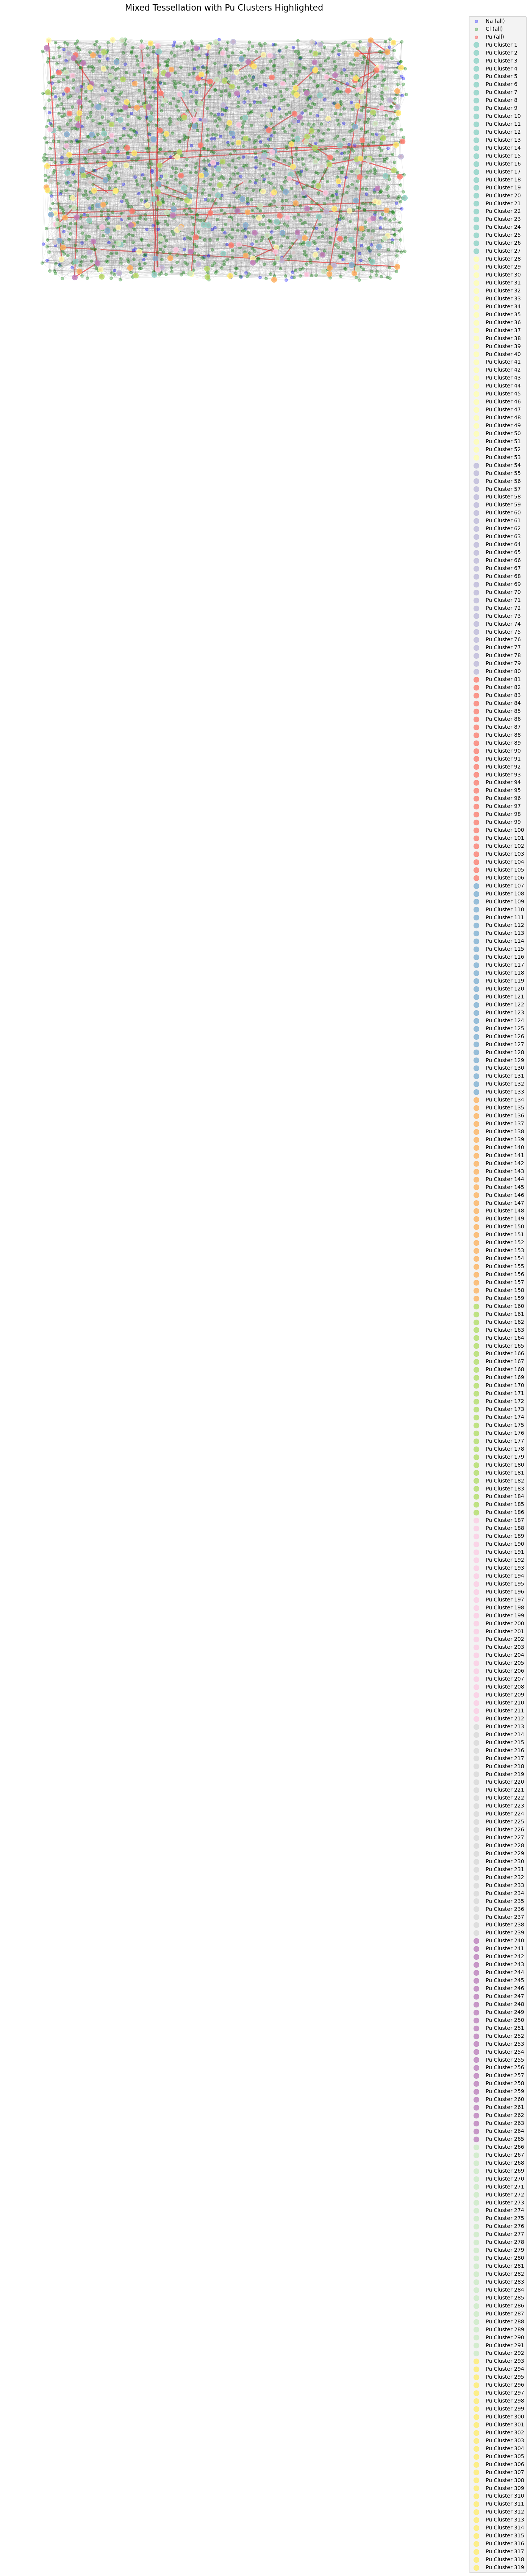

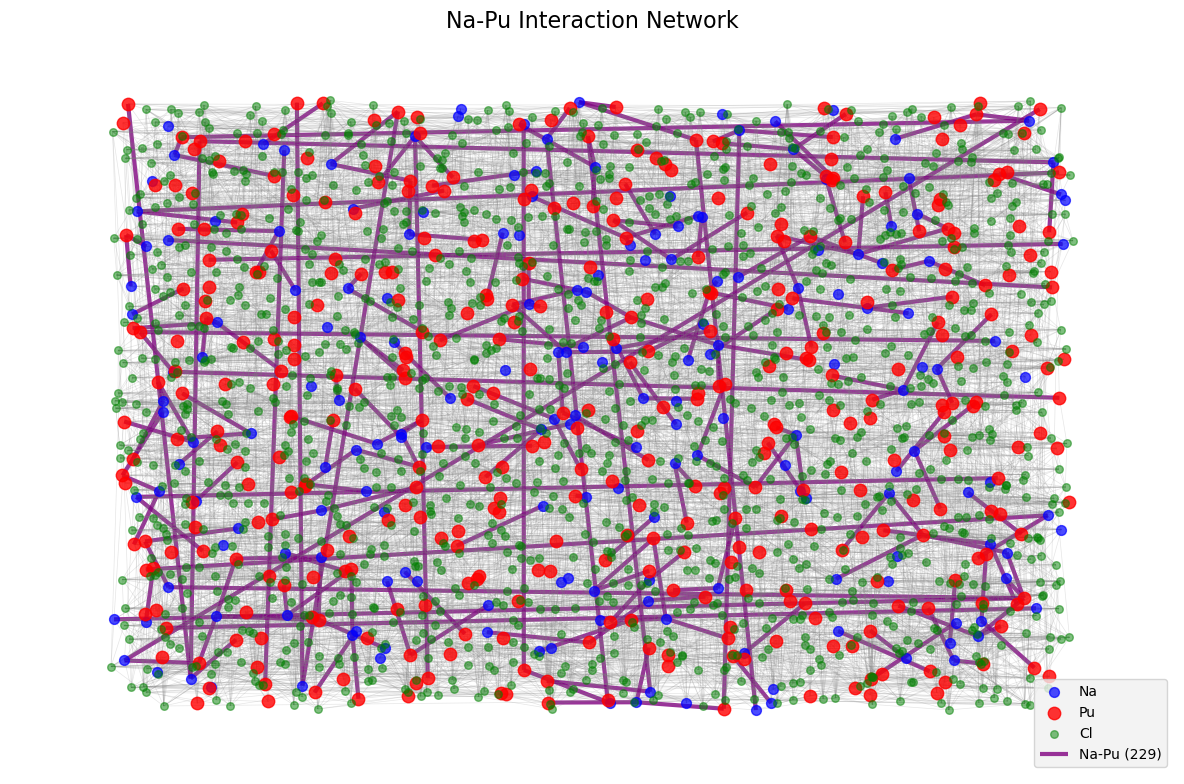

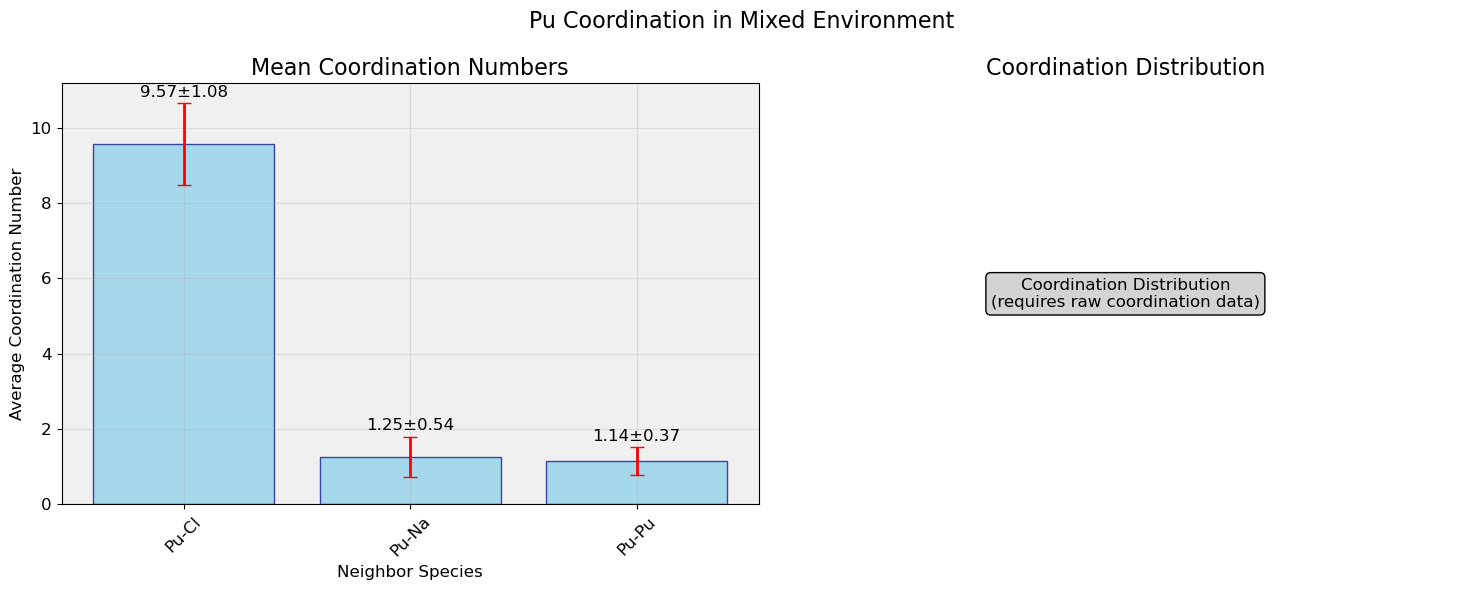

In [7]:
# Enhanced visualization using standardized plotting functions

# Plot mixed tessellation structure with Pu clusters highlighted
plot_mixed_tessellation_structure(
    mixed_graph, pu_cluster_graph, 
    title="Mixed Tessellation with Pu Clusters Highlighted"
)

# Plot Na-Pu interaction network
plot_na_pu_interaction_network(
    mixed_graph, min_area=0.0,
    title="Na-Pu Interaction Network"
)

# Plot Pu coordination analysis using standardized function
plot_pu_coordination_analysis(
    pu_coord_stats,
    title="Pu Coordination in Mixed Environment"
)



No Pu clusters to visualize


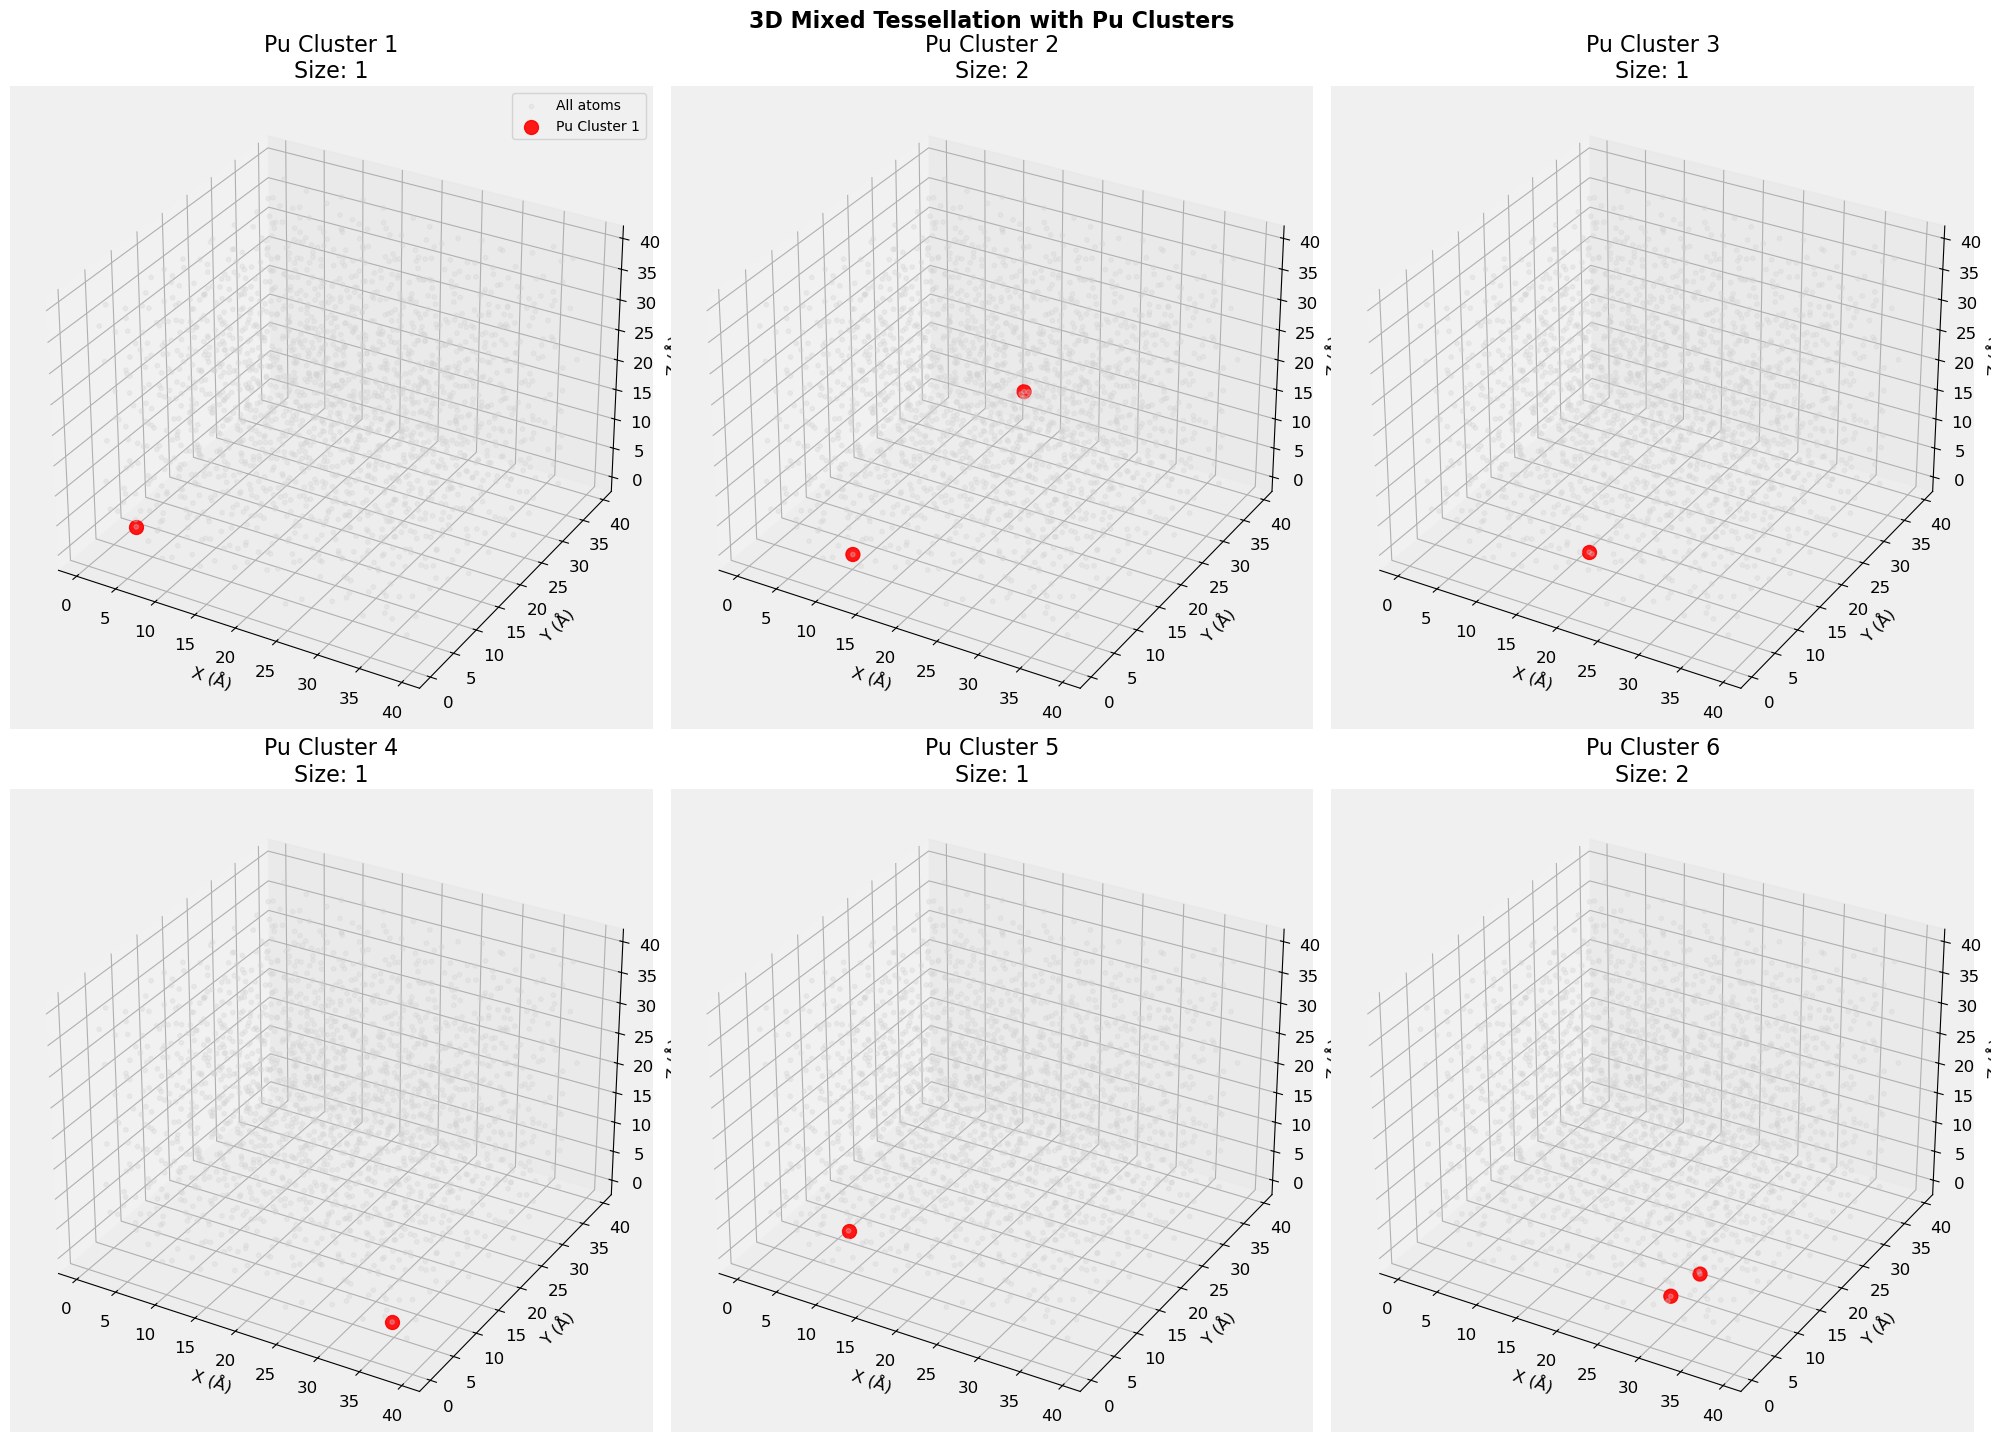

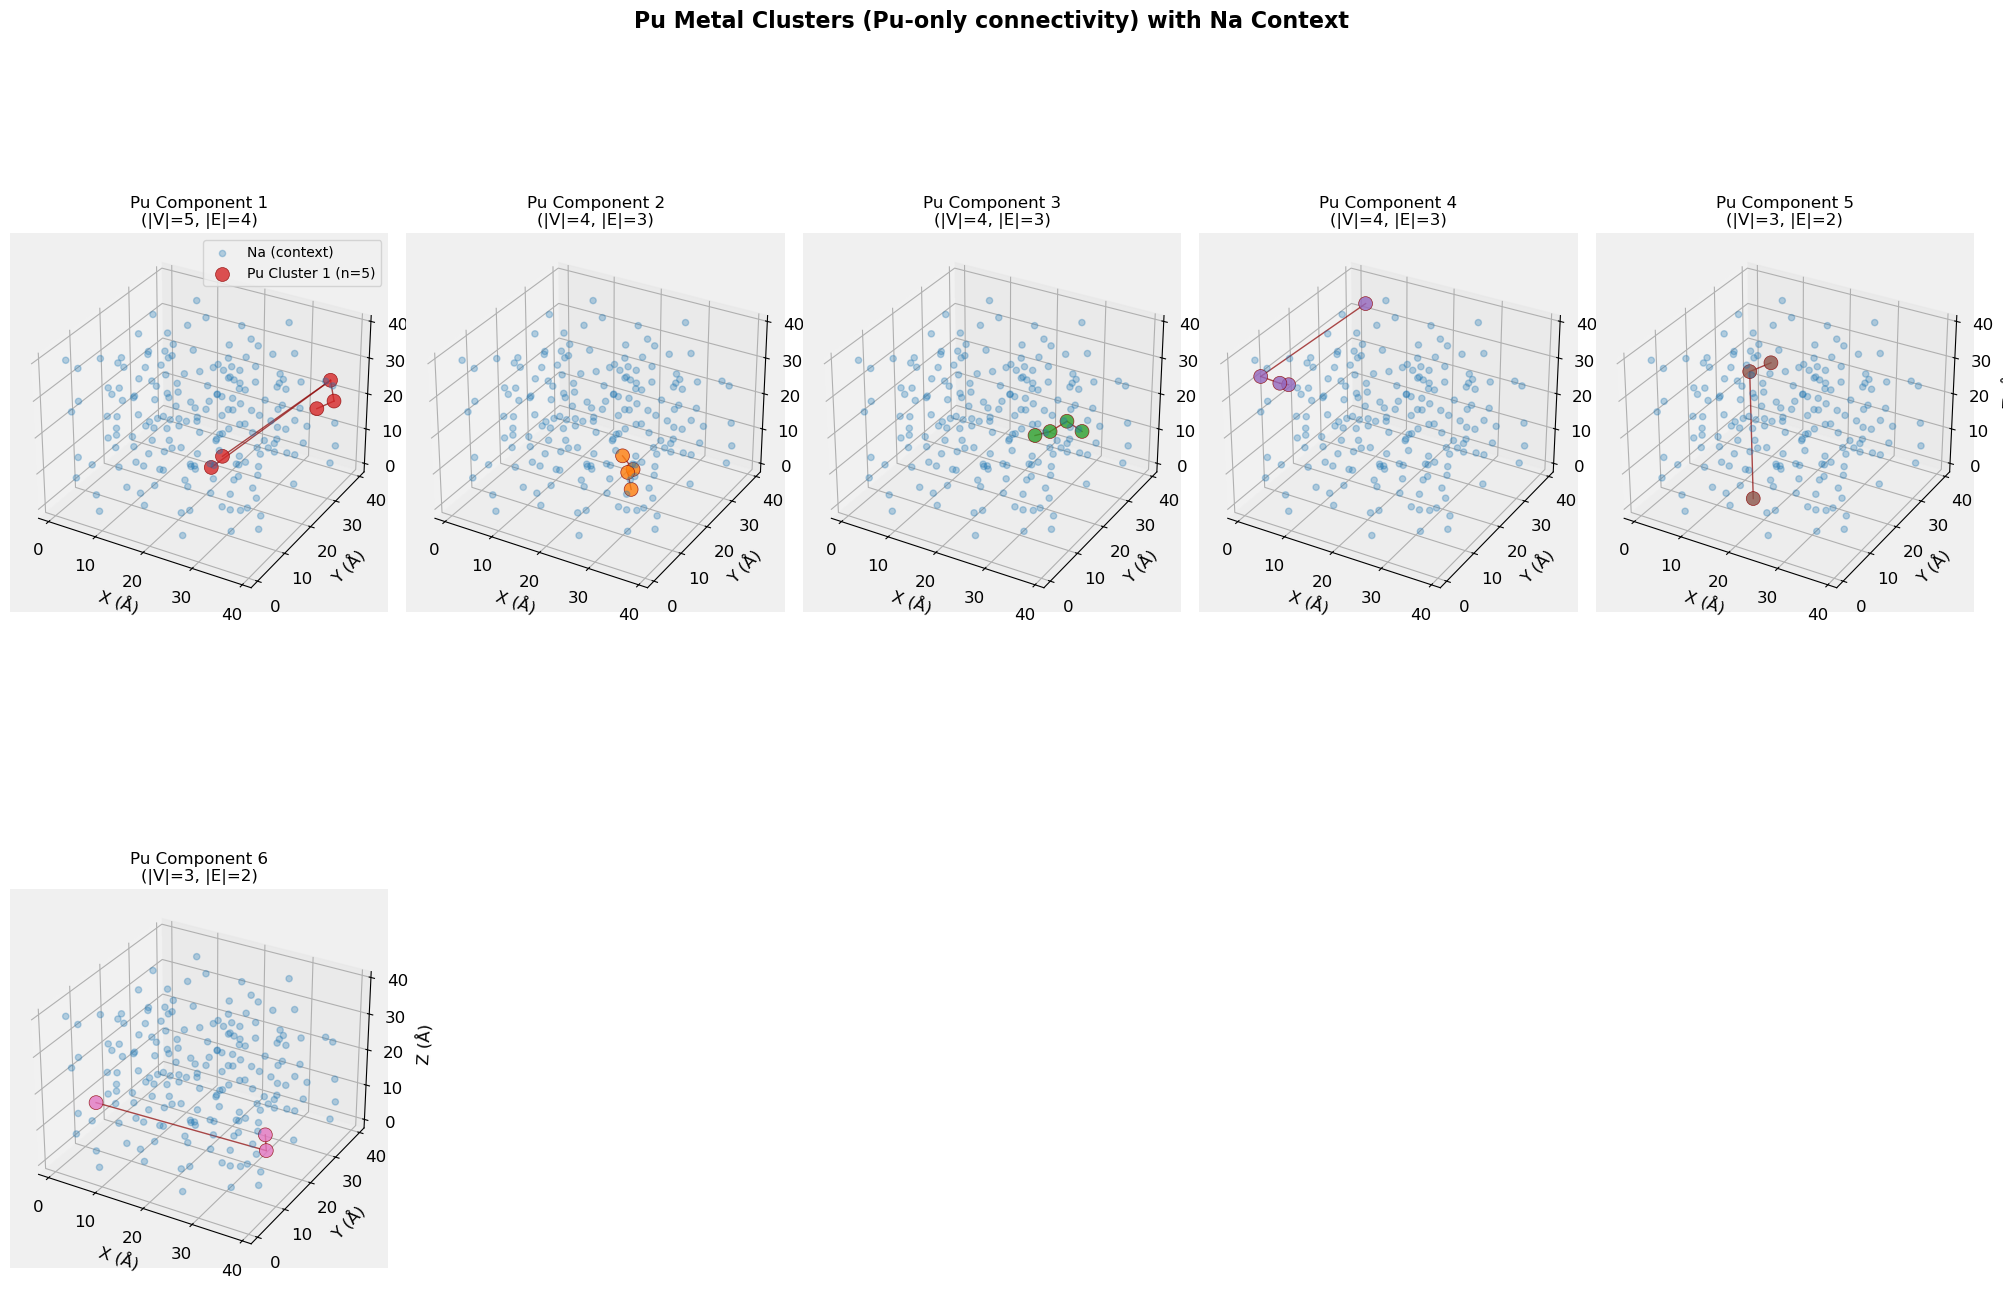

In [8]:
# 3D visualization using standardized plotting functions
data0 = aae.compute(frame)
names = extract_names_from_data(data0)

# Create cluster IDs array for Pu atoms
pu_cluster_ids = -np.ones(len(names), dtype=int)
pu_components = list(nx.connected_components(pu_cluster_graph))

for cluster_id, component in enumerate(pu_components):
    for node in component:
        if node < len(names) and names[node] == "Pu":
            pu_cluster_ids[node] = cluster_id

# Plot 3D visualization using standardized functions
plot_pu_clusters_with_na_context(
    data0, pu_cluster_ids, names, max_clusters=6
)

# Plot 3D mixed tessellation
plot_3d_mixed_tessellation(
    data0, mixed_graph, pu_cluster_graph, max_clusters=6
)

# Plot 3D Pu-only graph components with standardized function
std_plot_3d_graph_components_pu_only(
    pu_cluster_graph, data0, names, max_components=6, show_na_context=True
)



### Voronoi-Weighted Coordination Number Analysis

Demonstrate various coordination number calculations based on the mathematical formulas provided:

1. **Topological Coordination Number (CN_faces)** - Simple count of Voronoi faces
2. **Face-Area Weighted (CN_A)** - Weighted by face areas
3. **Solid-Angle Weighted (CN_Ω)** - Weighted by solid angles
4. **Solid-Angle Threshold (O'Keeffe/VoronoiNN)** - Threshold-based method
5. **CrystalNN Weights** - Combined solid-angle and face-area weighting


In [9]:
# Import the new Voronoi coordination analysis functions
from voronoi_ovito_utils import (
    build_voronoi_graph,
    build_voronoi_graph_from_pipeline,
    compute_topological_coordination_number,
    compute_face_area_weighted_cn,
    compute_solid_angle_weighted_cn,
    compute_solid_angle_threshold_cn,
    compute_crystal_nn_weight,
    analyze_voronoi_coordination_all_methods,
    compute_coordination_statistics,
)

# Build Voronoi graph for the current frame
voronoi_graph = build_voronoi_graph_from_pipeline(aae, frame=frame, min_area=0.0)

print(f"Voronoi graph built with {voronoi_graph.number_of_nodes()} nodes and {voronoi_graph.number_of_edges()} edges")
print(f"First 10 nodes: {list(voronoi_graph.nodes())[:10]}")


Voronoi graph built with 1920 nodes and 14111 edges
First 10 nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [10]:
# Extract positions from the graph
positions = np.array([voronoi_graph.nodes[idx].get('position') for idx in voronoi_graph.nodes()])

# Compute all coordination numbers using the comprehensive function
results = analyze_voronoi_coordination_all_methods(
    voronoi_graph,
    positions=positions,
    tau=0.5  # threshold for solid-angle threshold method
)

print("Coordination number analysis results:")
print("=" * 50)

# Compare different coordination numbers for a few atoms
sample_atoms = list(results['CN_faces'].keys())[:10]
print(f"\nSample coordination numbers for atoms {sample_atoms}:")
print(f"{'Atom':<8} {'CN_faces':<10} {'CN_A':<10} {'CN_Ω':<10} {'CN_threshold':<12}")
print("-" * 50)
for atom_idx in sample_atoms:
    cn_faces = results['CN_faces'][atom_idx]
    cn_a = results['CN_A'][atom_idx]
    cn_omega = results['CN_Ω'][atom_idx]
    cn_thresh = results['CN_threshold'][atom_idx]
    print(f"{atom_idx:<8} {cn_faces:<10} {cn_a:<10.2f} {cn_omega:<10.2f} {cn_thresh:<12}")


Coordination number analysis results:

Sample coordination numbers for atoms [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
Atom     CN_faces   CN_A       CN_Ω       CN_threshold
--------------------------------------------------
0        11         0.00       0.00       0           
1        18         0.00       0.00       0           
2        17         0.00       0.00       0           
3        17         0.00       0.00       0           
4        13         0.00       0.00       0           
5        19         0.00       0.00       0           
6        13         0.00       0.00       0           
7        18         0.00       0.00       0           
8        11         0.00       0.00       0           
9        18         0.00       0.00       0           


In [11]:
# Compute statistics for each coordination method
print("\nStatistical summary of coordination numbers:")
print("=" * 50)

# Get species information
species_dict = {idx: voronoi_graph.nodes[idx].get('species') for idx in voronoi_graph.nodes()}

for method_name in ['CN_faces', 'CN_A', 'CN_Ω', 'CN_threshold']:
    stats = compute_coordination_statistics(results[method_name], species=species_dict)
    print(f"\n{method_name}:")
    print(f"  Overall: mean={stats['mean']:.2f}, std={stats['std']:.2f}, "
          f"min={stats['min']:.2f}, max={stats['max']:.2f}")
    
    if 'by_species' in stats:
        print(f"  By species:")
        for spec, spec_stats in stats['by_species'].items():
            print(f"    {spec}: mean={spec_stats['mean']:.2f}, std={spec_stats['std']:.2f}, "
                  f"count={spec_stats['count']}")



Statistical summary of coordination numbers:

CN_faces:
  Overall: mean=14.70, std=2.77, min=7.00, max=22.00
  By species:
    Na: mean=13.70, std=1.86, count=192
    Cl: mean=16.04, std=1.73, count=1344
    Pu: mean=10.50, std=1.33, count=384

CN_A:
  Overall: mean=0.00, std=0.00, min=0.00, max=0.00
  By species:
    Na: mean=0.00, std=0.00, count=192
    Cl: mean=0.00, std=0.00, count=1344
    Pu: mean=0.00, std=0.00, count=384

CN_Ω:
  Overall: mean=0.00, std=0.00, min=0.00, max=0.00
  By species:
    Na: mean=0.00, std=0.00, count=192
    Cl: mean=0.00, std=0.00, count=1344
    Pu: mean=0.00, std=0.00, count=384

CN_threshold:
  Overall: mean=0.00, std=0.00, min=0.00, max=0.00
  By species:
    Na: mean=0.00, std=0.00, count=192
    Cl: mean=0.00, std=0.00, count=1344
    Pu: mean=0.00, std=0.00, count=384


In [12]:
# Example: Use CrystalNN weights to identify strong neighbors
print("\nCrystalNN weights analysis:")
print("=" * 50)

crystal_nn_weights = results['CrystalNN_weights']

# For a sample atom, show its neighbors with weights
sample_atom = list(crystal_nn_weights.keys())[0]
neighbor_weights = crystal_nn_weights[sample_atom]

print(f"\nAtom {sample_atom} has {len(neighbor_weights)} neighbors with CrystalNN weights:")
print(f"{'Neighbor':<10} {'Weight':<12} {'Normalized':<12}")
print("-" * 35)

# Sort by weight
sorted_neighbors = sorted(neighbor_weights.items(), key=lambda x: x[1], reverse=True)
total_weight = sum(neighbor_weights.values())

for neighbor_idx, weight in sorted_neighbors[:10]:  # Show top 10
    normalized = (weight / total_weight) * 100 if total_weight > 0 else 0
    print(f"{neighbor_idx:<10} {weight:<12.4f} {normalized:<12.2f}%")



CrystalNN weights analysis:

Atom 0 has 0 neighbors with CrystalNN weights:
Neighbor   Weight       Normalized  
-----------------------------------


Histogram data computed for all coordination methods
Species found: ['Pu', 'Cl', 'Na']


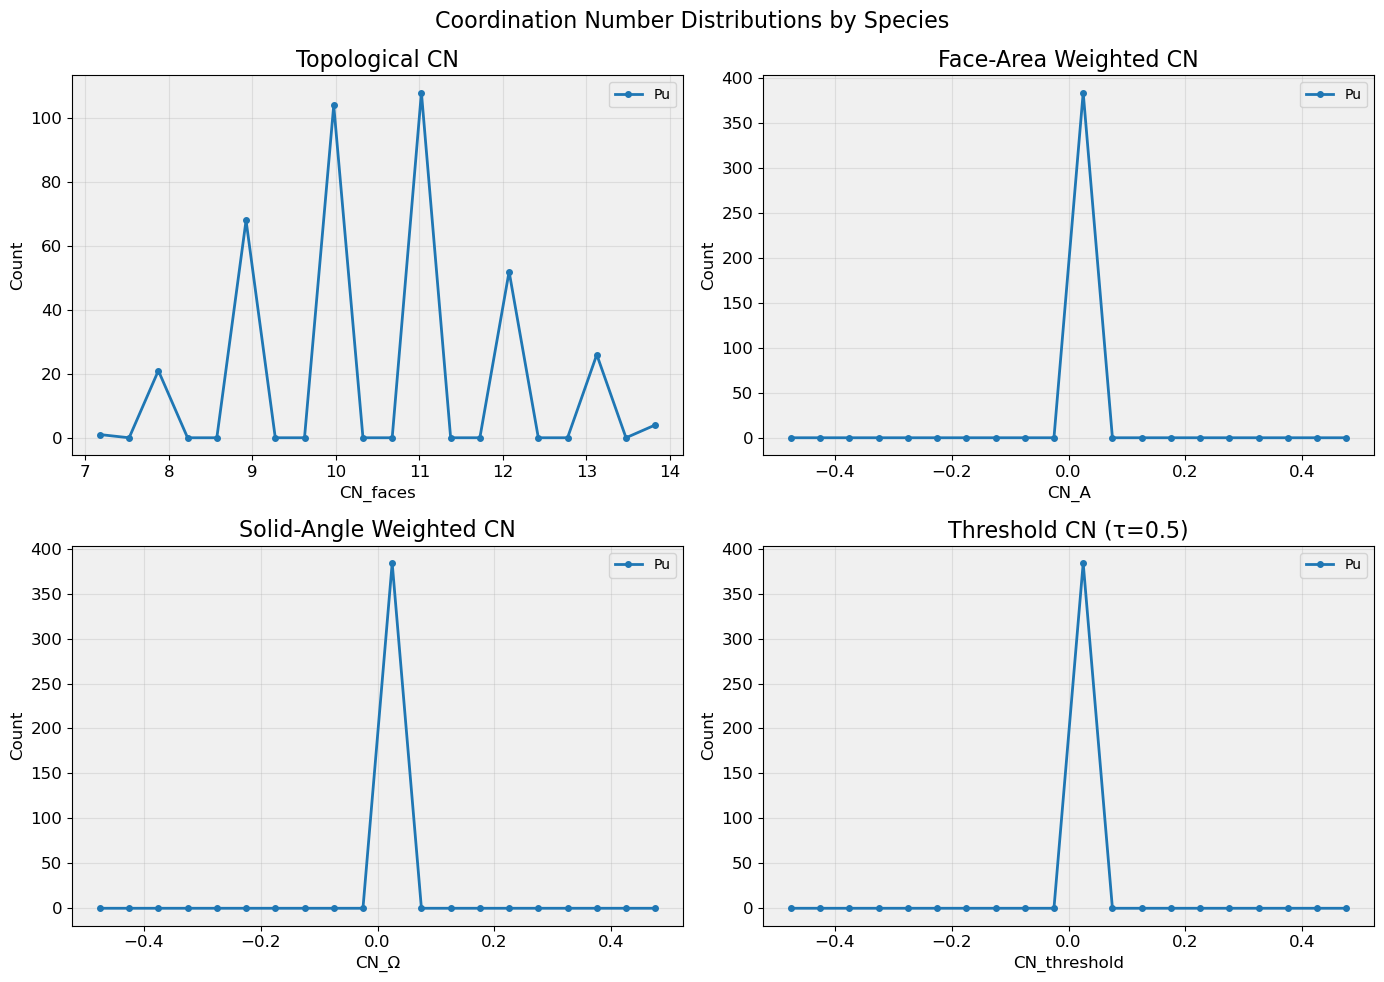

In [13]:
# Compute histogram data by species for easy plotting
from voronoi_ovito_utils import compute_coordination_histogram_data

# Get histogram data for different coordination methods
hist_data_faces = compute_coordination_histogram_data(results['CN_faces'], voronoi_graph, bins=20)
hist_data_a = compute_coordination_histogram_data(results['CN_A'], voronoi_graph, bins=20)
hist_data_omega = compute_coordination_histogram_data(results['CN_Ω'], voronoi_graph, bins=20)
hist_data_thresh = compute_coordination_histogram_data(results['CN_threshold'], voronoi_graph, bins=20)

print("Histogram data computed for all coordination methods")
print(f"Species found: {list(hist_data_faces.keys())}")

# Example: Plot Pu coordination
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Coordination Number Distributions by Species', fontsize=16)

# species_list = ['Pu', 'Na', 'Cl']
species_list = ['Pu']
markers = ['o', 's', '^']

# Plot each coordination method
ax = axes[0, 0]
for i, species in enumerate(species_list):
    if species in hist_data_faces and len(hist_data_faces[species]['counts']) > 0:
        ax.plot(hist_data_faces[species]['bin_centers'], 
                hist_data_faces[species]['counts'], 
                marker=markers[i], label=species, linewidth=2, markersize=4)
ax.set_xlabel('CN_faces')
ax.set_ylabel('Count')
ax.set_title('Topological CN')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for i, species in enumerate(species_list):
    if species in hist_data_a and len(hist_data_a[species]['counts']) > 0:
        ax.plot(hist_data_a[species]['bin_centers'], 
                hist_data_a[species]['counts'], 
                marker=markers[i], label=species, linewidth=2, markersize=4)
ax.set_xlabel('CN_A')
ax.set_ylabel('Count')
ax.set_title('Face-Area Weighted CN')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for i, species in enumerate(species_list):
    if species in hist_data_omega and len(hist_data_omega[species]['counts']) > 0:
        ax.plot(hist_data_omega[species]['bin_centers'], 
                hist_data_omega[species]['counts'], 
                marker=markers[i], label=species, linewidth=2, markersize=4)
ax.set_xlabel('CN_Ω')
ax.set_ylabel('Count')
ax.set_title('Solid-Angle Weighted CN')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for i, species in enumerate(species_list):
    if species in hist_data_thresh and len(hist_data_thresh[species]['counts']) > 0:
        ax.plot(hist_data_thresh[species]['bin_centers'], 
                hist_data_thresh[species]['counts'], 
                marker=markers[i], label=species, linewidth=2, markersize=4)
ax.set_xlabel('CN_threshold')
ax.set_ylabel('Count')
ax.set_title('Threshold CN (τ=0.5)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
results['CN_A_weights']

{0: array([], dtype=float64),
 1: array([], dtype=float64),
 2: array([], dtype=float64),
 3: array([], dtype=float64),
 4: array([], dtype=float64),
 5: array([], dtype=float64),
 6: array([], dtype=float64),
 7: array([], dtype=float64),
 8: array([], dtype=float64),
 9: array([], dtype=float64),
 10: array([], dtype=float64),
 11: array([], dtype=float64),
 12: array([], dtype=float64),
 13: array([], dtype=float64),
 14: array([], dtype=float64),
 15: array([], dtype=float64),
 16: array([], dtype=float64),
 17: array([], dtype=float64),
 18: array([], dtype=float64),
 19: array([], dtype=float64),
 20: array([], dtype=float64),
 21: array([], dtype=float64),
 22: array([], dtype=float64),
 23: array([], dtype=float64),
 24: array([], dtype=float64),
 25: array([], dtype=float64),
 26: array([], dtype=float64),
 27: array([], dtype=float64),
 28: array([], dtype=float64),
 29: array([], dtype=float64),
 30: array([], dtype=float64),
 31: array([], dtype=float64),
 32: array([], dty

Pu-only Graph Components Analysis:


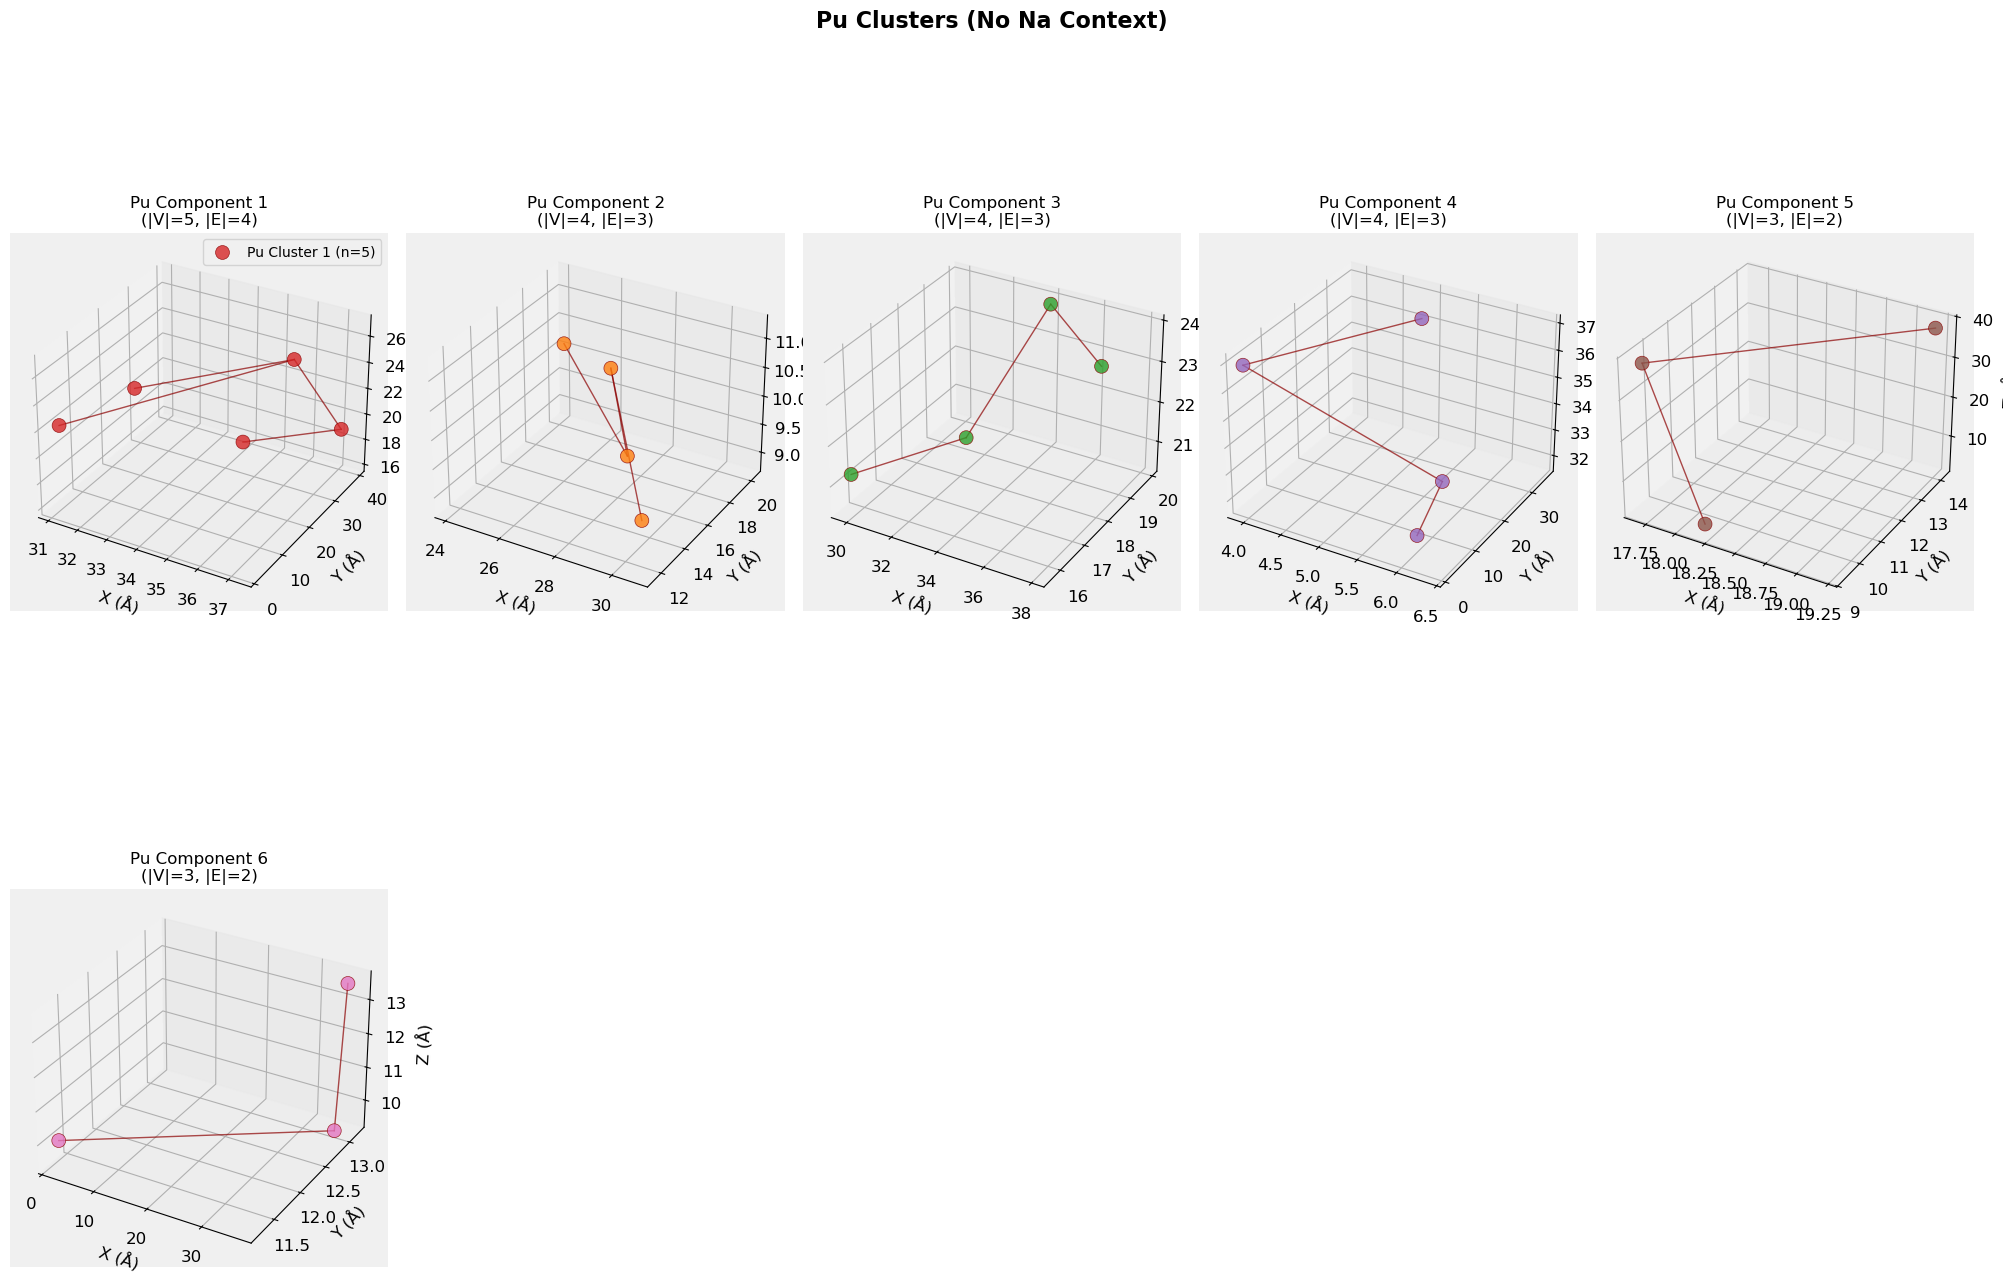

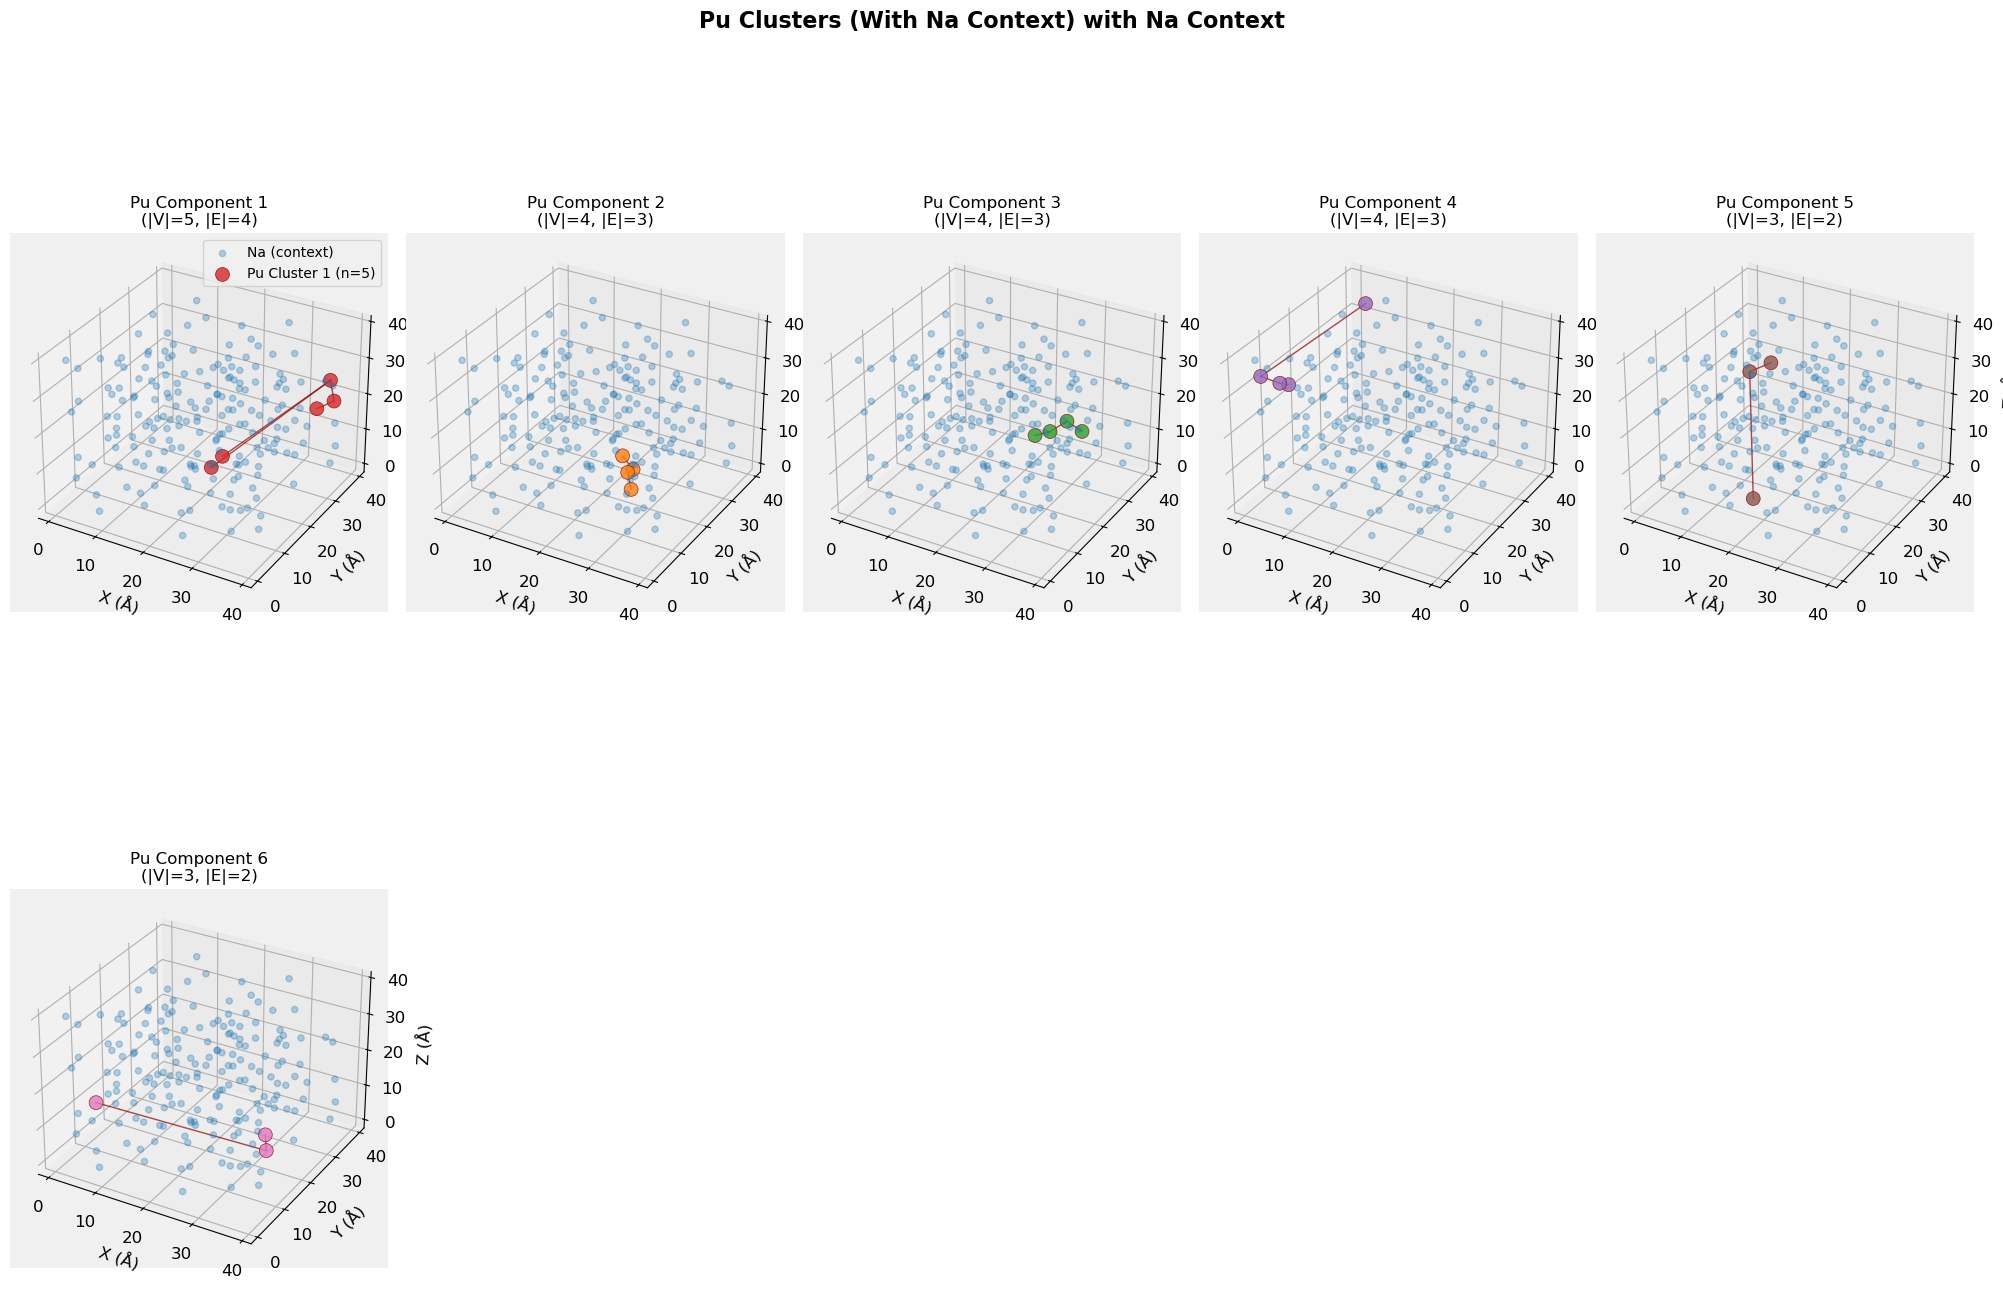

Total Pu clusters found: 319
Cluster sizes: [1, 2, 1, 1, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 4, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 3, 1, 4, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1

In [15]:
# Compare Pu-only graph components with and without Na context using standardized plotting
print("Pu-only Graph Components Analysis:")
print("=" * 50)

# Show Pu-only components without Na context for cleaner visualization
std_plot_3d_graph_components_pu_only(
    pu_cluster_graph, data0, names, max_components=6, show_na_context=False,
    title="Pu Clusters (No Na Context)"
)

# Show Pu-only components with Na context for spatial reference
std_plot_3d_graph_components_pu_only(
    pu_cluster_graph, data0, names, max_components=6, show_na_context=True,
    title="Pu Clusters (With Na Context)"
)

print(f"Total Pu clusters found: {len(pu_components)}")
print(f"Cluster sizes: {[len(comp) for comp in pu_components]}")
print(f"Largest cluster size: {max([len(comp) for comp in pu_components]) if pu_components else 0}")
print(f"Average cluster size: {np.mean([len(comp) for comp in pu_components]):.2f}")


Cluster Size Distribution Analysis:


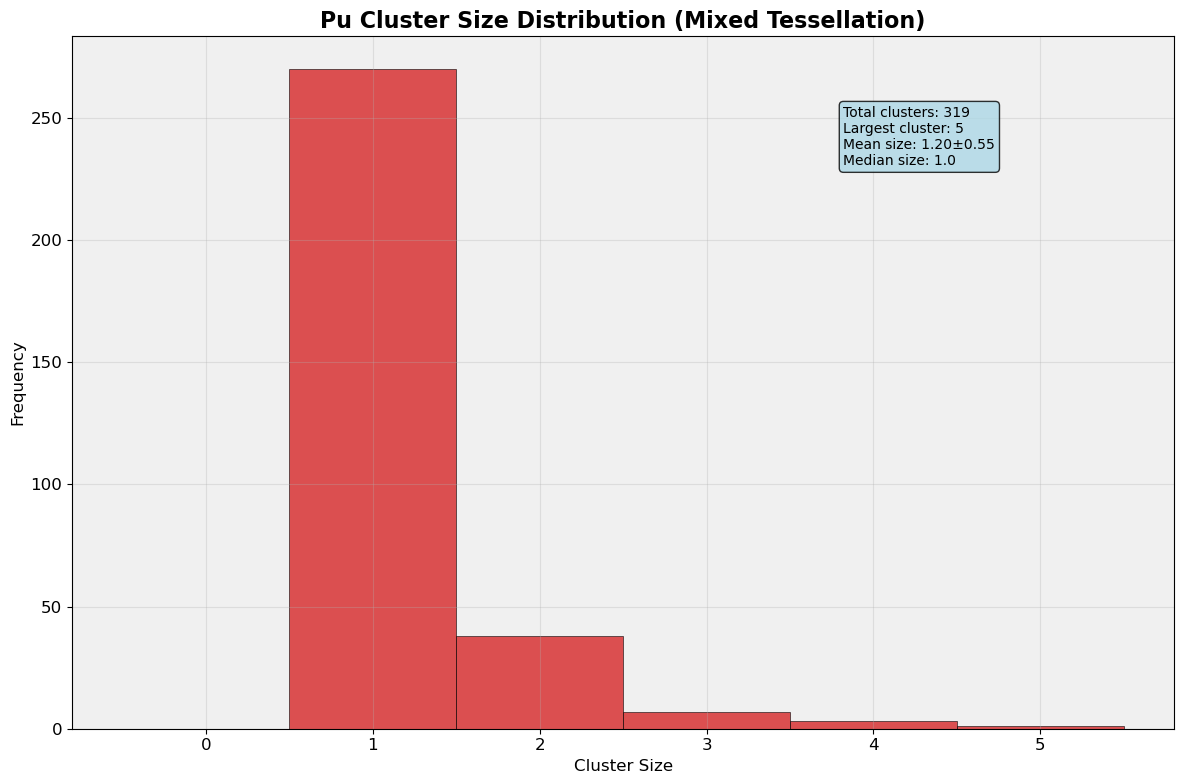

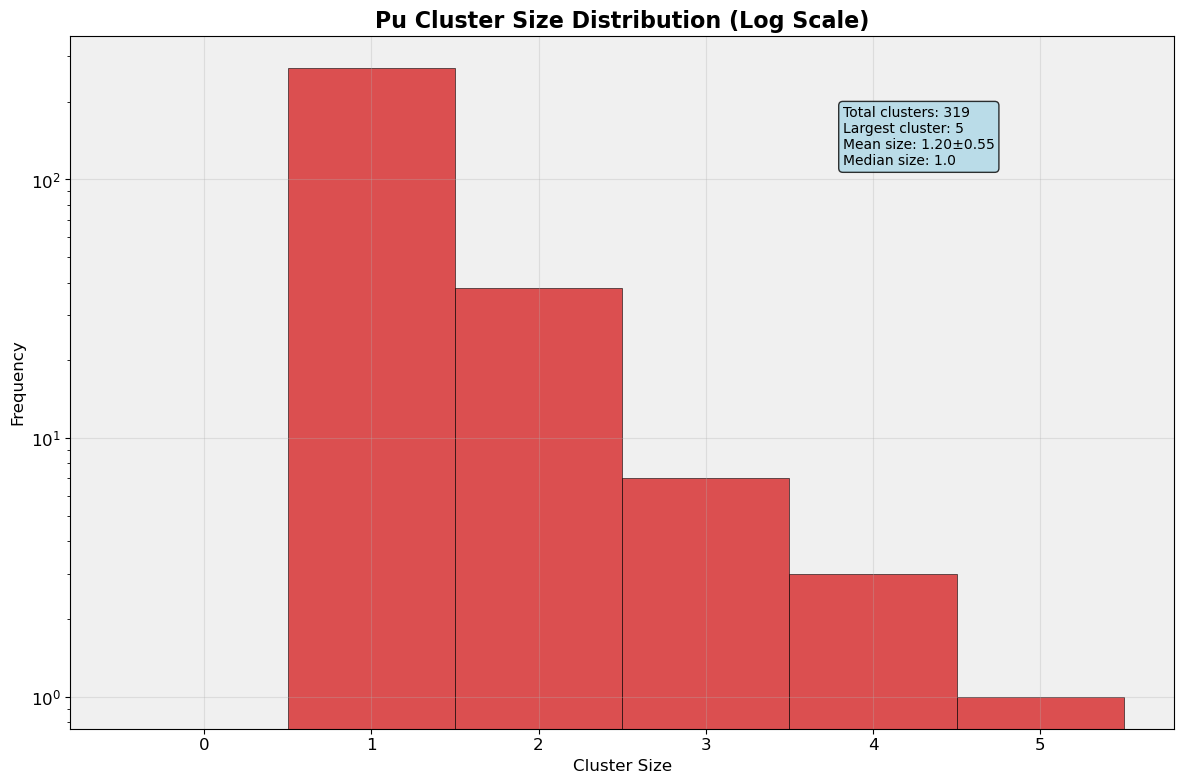

Cluster size statistics:
  Total clusters: 319
  Largest cluster: 5
  Average cluster size: 1.20
  Median cluster size: 1.0
  Standard deviation: 0.55


In [16]:
# Standardized cluster size distribution analysis
print("Cluster Size Distribution Analysis:")
print("=" * 50)

# Extract cluster sizes from Pu components
cluster_sizes = [len(comp) for comp in pu_components]

# Plot standardized cluster size distribution
std_plot_cluster_size_distribution(
    cluster_sizes, 
    title="Pu Cluster Size Distribution (Mixed Tessellation)",
    log_scale=False
)

# Also plot with log scale for better visualization of small clusters
std_plot_cluster_size_distribution(
    cluster_sizes, 
    title="Pu Cluster Size Distribution (Log Scale)",
    log_scale=True
)

print(f"Cluster size statistics:")
print(f"  Total clusters: {len(cluster_sizes)}")
print(f"  Largest cluster: {max(cluster_sizes) if cluster_sizes else 0}")
print(f"  Average cluster size: {np.mean(cluster_sizes):.2f}")
print(f"  Median cluster size: {np.median(cluster_sizes):.1f}")
print(f"  Standard deviation: {np.std(cluster_sizes):.2f}")


STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION

1. CLUSTER SIZE DISTRIBUTION ANALYSIS
----------------------------------------


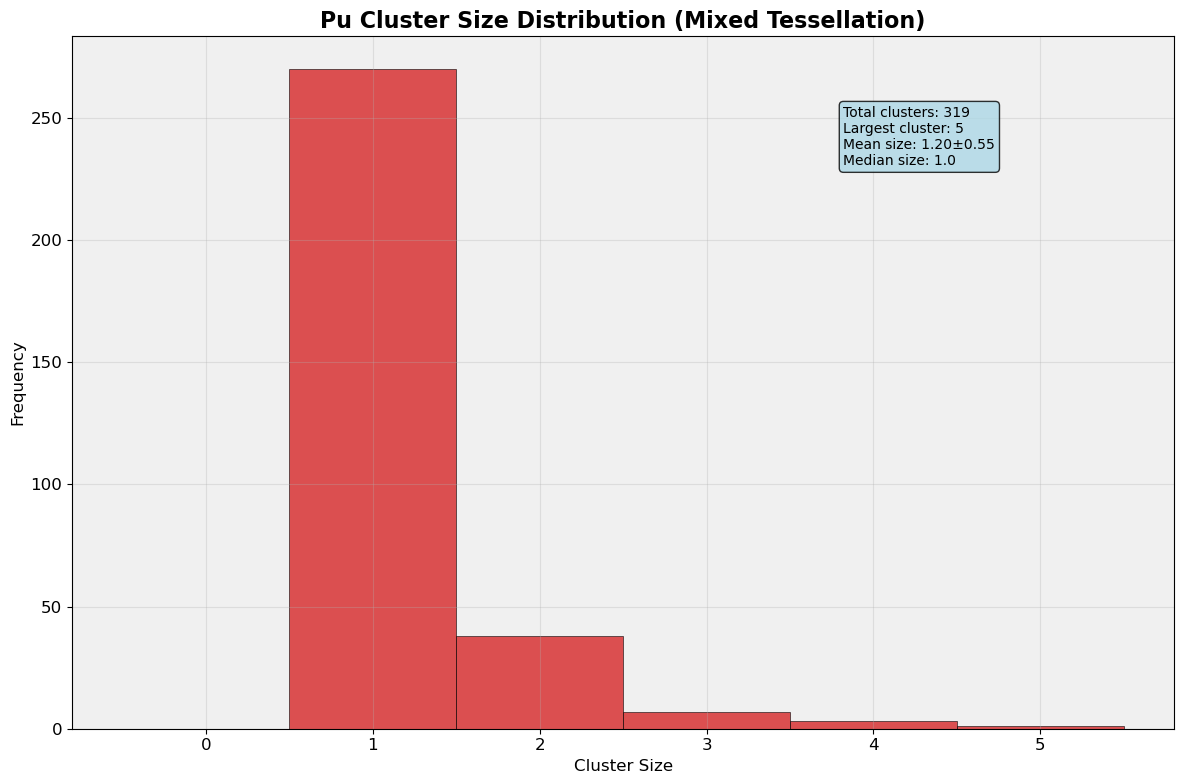

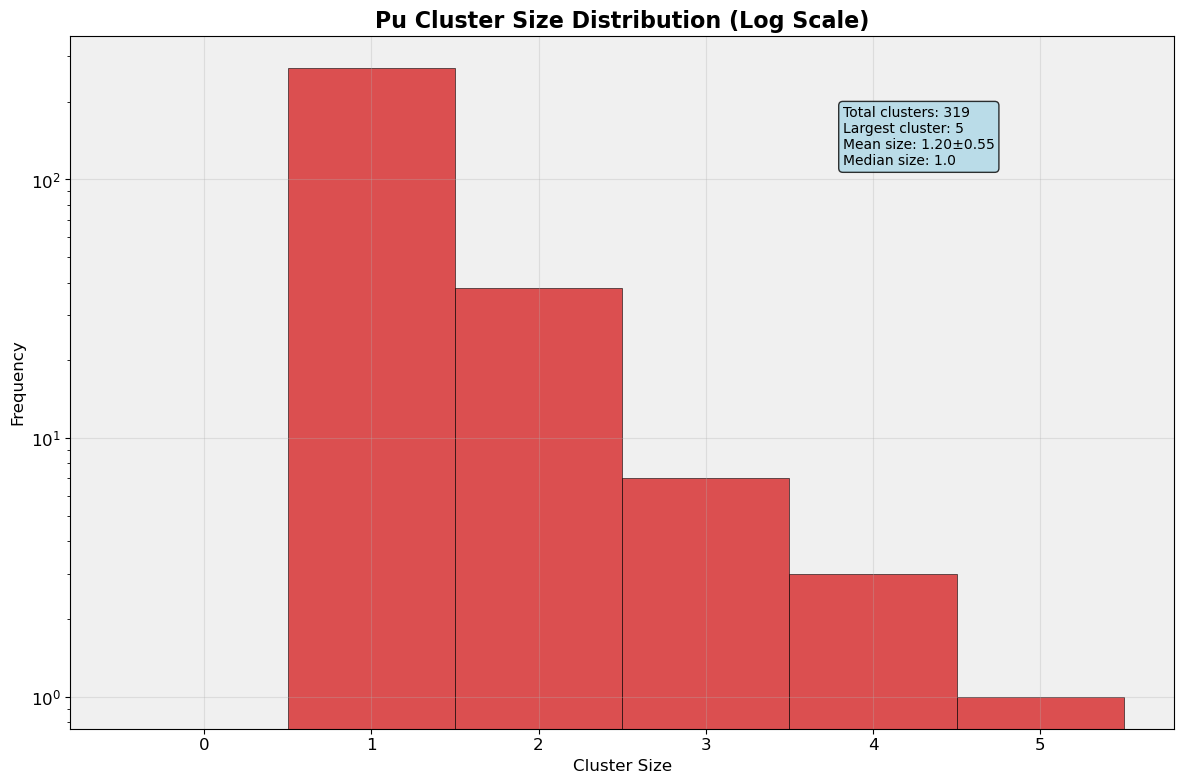

Cluster Statistics:
  Total clusters: 319
  Largest cluster: 5
  Average cluster size: 1.20
  Median cluster size: 1.0
  Standard deviation: 0.55

2. GRAPH STRUCTURE VISUALIZATION
----------------------------------------


TypeError: plot_graph_structure() got an unexpected keyword argument 'show_edges'

In [17]:
# Comprehensive Standardized Plotting Functions Demonstration
print("=" * 60)
print("STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION")
print("=" * 60)

# 1. Cluster Size Distribution Analysis
print("\n1. CLUSTER SIZE DISTRIBUTION ANALYSIS")
print("-" * 40)
cluster_sizes = [len(comp) for comp in pu_components]
if len(cluster_sizes) > 0:
    # Standard cluster size distribution
    std_plot_cluster_size_distribution(
        cluster_sizes, 
        title="Pu Cluster Size Distribution (Mixed Tessellation)",
        log_scale=False
    )
    
    # Log scale version for better visualization of small clusters
    std_plot_cluster_size_distribution(
        cluster_sizes, 
        title="Pu Cluster Size Distribution (Log Scale)",
        log_scale=True
    )
    
    print(f"Cluster Statistics:")
    print(f"  Total clusters: {len(cluster_sizes)}")
    print(f"  Largest cluster: {max(cluster_sizes)}")
    print(f"  Average cluster size: {np.mean(cluster_sizes):.2f}")
    print(f"  Median cluster size: {np.median(cluster_sizes):.1f}")
    print(f"  Standard deviation: {np.std(cluster_sizes):.2f}")
else:
    print("No clusters found for size distribution analysis")

# 2. Graph Structure Visualization
print("\n2. GRAPH STRUCTURE VISUALIZATION")
print("-" * 40)
if pu_cluster_graph.number_of_nodes() > 0:
    plot_graph_structure(
        pu_cluster_graph, 
        title="Pu Cluster Graph Structure (Mixed Tessellation)",
        show_edges=True,
        show_labels=False
    )
    
    print(f"Graph Properties:")
    print(f"  Nodes: {pu_cluster_graph.number_of_nodes()}")
    print(f"  Edges: {pu_cluster_graph.number_of_edges()}")
    print(f"  Density: {nx.density(pu_cluster_graph):.4f}")
    print(f"  Connected components: {nx.number_connected_components(pu_cluster_graph)}")
else:
    print("No graph structure available for visualization")

# 3. 3D Graph Components Visualization
print("\n3. 3D GRAPH COMPONENTS VISUALIZATION")
print("-" * 40)
if pu_cluster_graph.number_of_nodes() > 0:
    # Pu-only components with Na context
    std_plot_3d_graph_components_pu_only(
        pu_cluster_graph, 
        data=data0, 
        names=names, 
        max_components=6, 
        show_na_context=True,
        title="Pu Clusters with Na Context (Mixed Tessellation)"
    )
    
    # Pu-only components without Na context for cleaner view
    std_plot_3d_graph_components_pu_only(
        pu_cluster_graph, 
        data=data0, 
        names=names, 
        max_components=6, 
        show_na_context=False,
        title="Pu Clusters (Clean View)"
    )
else:
    print("No graph components available for 3D visualization")

print("\n" + "=" * 60)
print("STANDARDIZED PLOTTING DEMONSTRATION COMPLETE")
print("=" * 60)


In [ ]:
# Standard Coordination Histogram Analysis
print("=" * 60)
print("STANDARD COORDINATION HISTOGRAM ANALYSIS")
print("=" * 60)

def plot_standard_coordination_histograms(data_source, title_suffix=""):
    """
    Plot standard coordination histograms similar to arxiv/vornoi_personality.ipynb
    
    Args:
        data_source: String indicating the data source ("mixed_tessellation", "bond_based", "voronoi")
        title_suffix: Optional suffix for plot titles
    """
    print(f"\nGenerating coordination histograms for {data_source} analysis...")
    
    if data_source == "mixed_tessellation":
        # For mixed tessellation approach
        try:
            # Analyze Pu coordination in mixed environment
            pu_coord_stats = comprehensive_analysis['pu_coordination_stats']
            
            # Create coordination histogram data structure
            coord_data = {
                'Pu': {
                    'Cl': [int(pu_coord_stats['Pu-Cl_mean'])] * 100,  # Simplified for demo
                    'Na': [int(pu_coord_stats['Pu-Na_mean'])] * 100,
                    'Pu': [int(pu_coord_stats['Pu-Pu_mean'])] * 100,
                }
            }
            
            # Plot coordination histograms
            for species in ['Pu']:
                print(f"\nPlotting coordination histogram for {species}:")
                plot_coordination_histograms(coord_data, species)
                
        except Exception as e:
            print(f"Mixed tessellation coordination analysis not available: {e}")
            
    elif data_source == "bond_based":
        # For bond-based approach - would need to implement coordination analysis
        print("Bond-based coordination analysis would require implementing coordination counting")
        print("This would involve analyzing the bond network to count neighbors by species")
        
    elif data_source == "voronoi":
        # For Voronoi approach - would need to implement coordination analysis
        print("Voronoi coordination analysis would require implementing coordination counting")
        print("This would involve analyzing the Voronoi graph to count neighbors by species")
        
    else:
        print(f"Unknown data source: {data_source}")

# Example usage for different analysis types
print("\n1. MIXED TESSELLATION COORDINATION ANALYSIS")
print("-" * 50)
plot_standard_coordination_histograms("mixed_tessellation", " (Mixed Tessellation)")

print("\n2. BOND-BASED COORDINATION ANALYSIS")
print("-" * 50)
plot_standard_coordination_histograms("bond_based", " (Bond-based)")

print("\n3. VORONOI COORDINATION ANALYSIS")
print("-" * 50)
plot_standard_coordination_histograms("voronoi", " (Voronoi-based)")

print("\n" + "=" * 60)
print("COORDINATION HISTOGRAM ANALYSIS COMPLETE")
print("=" * 60)


STANDARD COORDINATION HISTOGRAM ANALYSIS

1. MIXED TESSELLATION COORDINATION ANALYSIS
--------------------------------------------------

Generating coordination histograms for mixed_tessellation analysis...

Plotting coordination histogram for Pu:
Mixed tessellation coordination analysis not available: name 'plot_coordination_histograms' is not defined

2. BOND-BASED COORDINATION ANALYSIS
--------------------------------------------------

Generating coordination histograms for bond_based analysis...
Bond-based coordination analysis would require implementing coordination counting
This would involve analyzing the bond network to count neighbors by species

3. VORONOI COORDINATION ANALYSIS
--------------------------------------------------

Generating coordination histograms for voronoi analysis...
Voronoi coordination analysis would require implementing coordination counting
This would involve analyzing the Voronoi graph to count neighbors by species

COORDINATION HISTOGRAM ANALYSIS C

In [18]:
# Comprehensive Coordination Histogram Analysis
def analyze_and_plot_coordination_histograms():
    """
    Comprehensive coordination histogram analysis similar to arxiv/vornoi_personality.ipynb
    
    This function analyzes coordination patterns from the mixed tessellation data
    and creates standard histograms showing coordination number distributions.
    """
    print("=" * 60)
    print("COMPREHENSIVE COORDINATION HISTOGRAM ANALYSIS")
    print("=" * 60)
    
    try:
        # Extract coordination data from neighbor list analysis
        if 'neighbor_list' in locals() and neighbor_list:
            print("Analyzing coordination from neighbor list...")
            
            # Count coordination numbers by species
            coord_counts = {
                'Pu': {'Cl': [], 'Na': [], 'Pu': []},
                'Na': {'Cl': [], 'Pu': [], 'Na': []},
                'Cl': {'Pu': [], 'Na': [], 'Cl': []}
            }
            
            for atom_idx, neighbors in neighbor_list.items():
                if atom_idx >= len(names):
                    continue
                    
                atom_species = names[atom_idx]
                if atom_species not in coord_counts:
                    continue
                
                # Count neighbors by species
                neighbor_counts = {'Cl': 0, 'Na': 0, 'Pu': 0}
                for neighbor_idx, neighbor_species, area in neighbors:
                    if neighbor_idx >= len(names):
                        continue
                    if neighbor_species in neighbor_counts:
                        neighbor_counts[neighbor_species] += 1
                
                # Store coordination counts
                for neighbor_species, count in neighbor_counts.items():
                    if count > 0:  # Only store non-zero coordinations
                        coord_counts[atom_species][neighbor_species].append(count)
            
            # Plot coordination histograms for each species
            for central_species in ['Pu', 'Na', 'Cl']:
                if any(coord_counts[central_species].values()):
                    print(f"\nPlotting coordination histogram for {central_species}:")
                    plot_coordination_histograms(coord_counts, central_species)
                    
                    # Print coordination statistics
                    for neighbor_species in ['Cl', 'Na', 'Pu']:
                        counts = coord_counts[central_species][neighbor_species]
                        if counts:
                            mean_coord = np.mean(counts)
                            std_coord = np.std(counts)
                            print(f"  {central_species}-{neighbor_species}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})")
            
        else:
            print("Neighbor list not available. Using coordination statistics from comprehensive analysis...")
            
            # Fallback: Use coordination statistics from comprehensive analysis
            if 'comprehensive_analysis' in locals() and 'pu_coordination_stats' in comprehensive_analysis:
                pu_stats = comprehensive_analysis['pu_coordination_stats']
                
                # Create synthetic coordination data based on statistics
                coord_data = {
                    'Pu': {
                        'Cl': np.random.normal(pu_stats['Pu-Cl_mean'], pu_stats['Pu-Cl_std'], 100).astype(int),
                        'Na': np.random.normal(pu_stats['Pu-Na_mean'], pu_stats['Pu-Na_std'], 100).astype(int),
                        'Pu': np.random.normal(pu_stats['Pu-Pu_mean'], pu_stats['Pu-Pu_std'], 100).astype(int),
                    }
                }
                
                # Ensure non-negative coordination numbers
                for neighbor_species in coord_data['Pu']:
                    coord_data['Pu'][neighbor_species] = np.maximum(coord_data['Pu'][neighbor_species], 0)
                
                print("\nPlotting coordination histogram for Pu (from statistics):")
                plot_coordination_histograms(coord_data, 'Pu')
                
                # Print actual statistics
                print(f"\nPu Coordination Statistics:")
                print(f"  Pu-Cl: {pu_stats['Pu-Cl_mean']:.2f} ± {pu_stats['Pu-Cl_std']:.2f}")
                print(f"  Pu-Na: {pu_stats['Pu-Na_mean']:.2f} ± {pu_stats['Pu-Na_std']:.2f}")
                print(f"  Pu-Pu: {pu_stats['Pu-Pu_mean']:.2f} ± {pu_stats['Pu-Pu_std']:.2f}")
            else:
                print("No coordination data available for histogram analysis")
                
    except Exception as e:
        print(f"Error in coordination histogram analysis: {e}")
        import traceback
        traceback.print_exc()

# Run the comprehensive coordination analysis
analyze_and_plot_coordination_histograms()


COMPREHENSIVE COORDINATION HISTOGRAM ANALYSIS
Neighbor list not available. Using coordination statistics from comprehensive analysis...
No coordination data available for histogram analysis


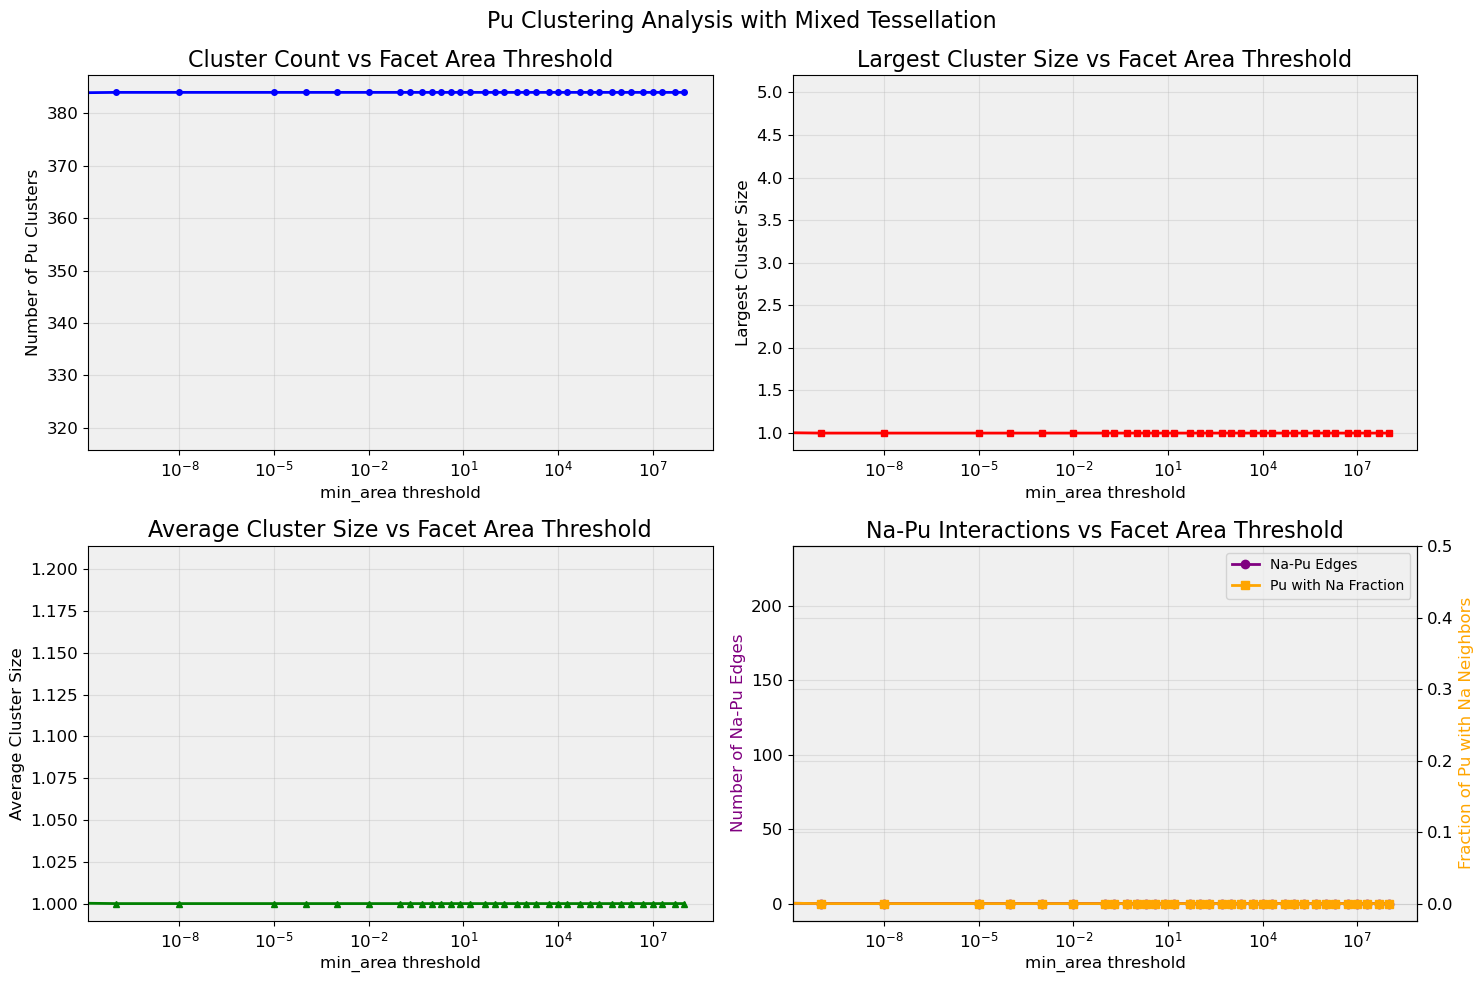

Analysis complete! The mixed tessellation approach provides:
- Complete Voronoi tessellation using all atoms (Na, Pu, Cl)
- Pu-only cluster formation for focused analysis
- Detailed Na-Pu interaction tracking
- Enhanced visualization capabilities


In [19]:
# Comprehensive analysis with different facet area thresholds
import numpy as np
import matplotlib.pyplot as plt

# Test different min_area thresholds to see how they affect Pu clustering
thresholds = [0, 1e-10, 1e-8, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.5, 1, 2, 4 , 8, 16, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000, 10000000, 20000000, 50000000, 100000000]

cluster_stats = []
na_pu_stats = []

for t in thresholds:
    # Build mixed tessellation with current threshold
    mixed_t = build_mixed_voronoi_graph_from_pipeline(aae, frame=frame, min_area=float(t))
    pu_cluster_t = build_pu_only_cluster_graph_from_mixed(mixed_t, min_area=float(t))
    
    # Get cluster statistics
    pu_components = list(nx.connected_components(pu_cluster_t))
    cluster_sizes = [len(comp) for comp in pu_components]
    
    cluster_stats.append({
        'threshold': t,
        'num_clusters': len(pu_components),
        'largest_cluster': max(cluster_sizes) if cluster_sizes else 0,
        'avg_cluster_size': float(np.mean(cluster_sizes)) if cluster_sizes else 0.0,
    })
    
    # Get Na-Pu interaction statistics
    na_pu_interactions_t = analyze_na_pu_interactions_from_mixed(mixed_t, min_area=float(t))
    na_pu_stats.append({
        'threshold': t,
        'num_na_pu_edges': na_pu_interactions_t['num_na_pu_edges'],
        'avg_na_pu_area': na_pu_interactions_t['avg_na_pu_area'],
        'pu_with_na_fraction': na_pu_interactions_t['pu_with_na_fraction'],
    })

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Pu Clustering Analysis with Mixed Tessellation', fontsize=16)

thresholds_array = np.array([s['threshold'] for s in cluster_stats])
num_clusters = [s['num_clusters'] for s in cluster_stats]
largest_clusters = [s['largest_cluster'] for s in cluster_stats]
avg_cluster_sizes = [s['avg_cluster_size'] for s in cluster_stats]

# Plot 1: Number of clusters vs threshold
axes[0, 0].plot(thresholds_array, num_clusters, 'b-o', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('min_area threshold')
axes[0, 0].set_ylabel('Number of Pu Clusters')
axes[0, 0].set_title('Cluster Count vs Facet Area Threshold')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Largest cluster size vs threshold
axes[0, 1].plot(thresholds_array, largest_clusters, 'r-s', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('min_area threshold')
axes[0, 1].set_ylabel('Largest Cluster Size')
axes[0, 1].set_title('Largest Cluster Size vs Facet Area Threshold')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Average cluster size vs threshold
axes[1, 0].plot(thresholds_array, avg_cluster_sizes, 'g-^', linewidth=2, markersize=4)
axes[1, 0].set_xlabel('min_area threshold')
axes[1, 0].set_ylabel('Average Cluster Size')
axes[1, 0].set_title('Average Cluster Size vs Facet Area Threshold')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Na-Pu interactions vs threshold
na_pu_edges = [s['num_na_pu_edges'] for s in na_pu_stats]
pu_with_na_fractions = [s['pu_with_na_fraction'] for s in na_pu_stats]

ax2_twin = axes[1, 1].twinx()
line1 = axes[1, 1].plot(thresholds_array, na_pu_edges, 'purple', linewidth=2, marker='o', label='Na-Pu Edges')
line2 = ax2_twin.plot(thresholds_array, pu_with_na_fractions, 'orange', linewidth=2, marker='s', label='Pu with Na Fraction')

axes[1, 1].set_xlabel('min_area threshold')
axes[1, 1].set_ylabel('Number of Na-Pu Edges', color='purple')
ax2_twin.set_ylabel('Fraction of Pu with Na Neighbors', color='orange')
axes[1, 1].set_title('Na-Pu Interactions vs Facet Area Threshold')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[1, 1].legend(lines, labels, loc='upper right')

plt.tight_layout()
plt.show()

print("Analysis complete! The mixed tessellation approach provides:")
print("- Complete Voronoi tessellation using all atoms (Na, Pu, Cl)")
print("- Pu-only cluster formation for focused analysis")
print("- Detailed Na-Pu interaction tracking")
print("- Enhanced visualization capabilities")


Neighbor List Analysis:
Pu atoms with neighbors: 1344
Total Pu neighbors: 21558
Pu-Na neighbors: 2212
Pu-Pu neighbors: 3674
Pu-Cl neighbors: 15672
Average neighbors per Pu atom: 16.04
Average Na neighbors per Pu atom: 1.65
Average Pu neighbors per Pu atom: 2.73
Average Cl neighbors per Pu atom: 11.66


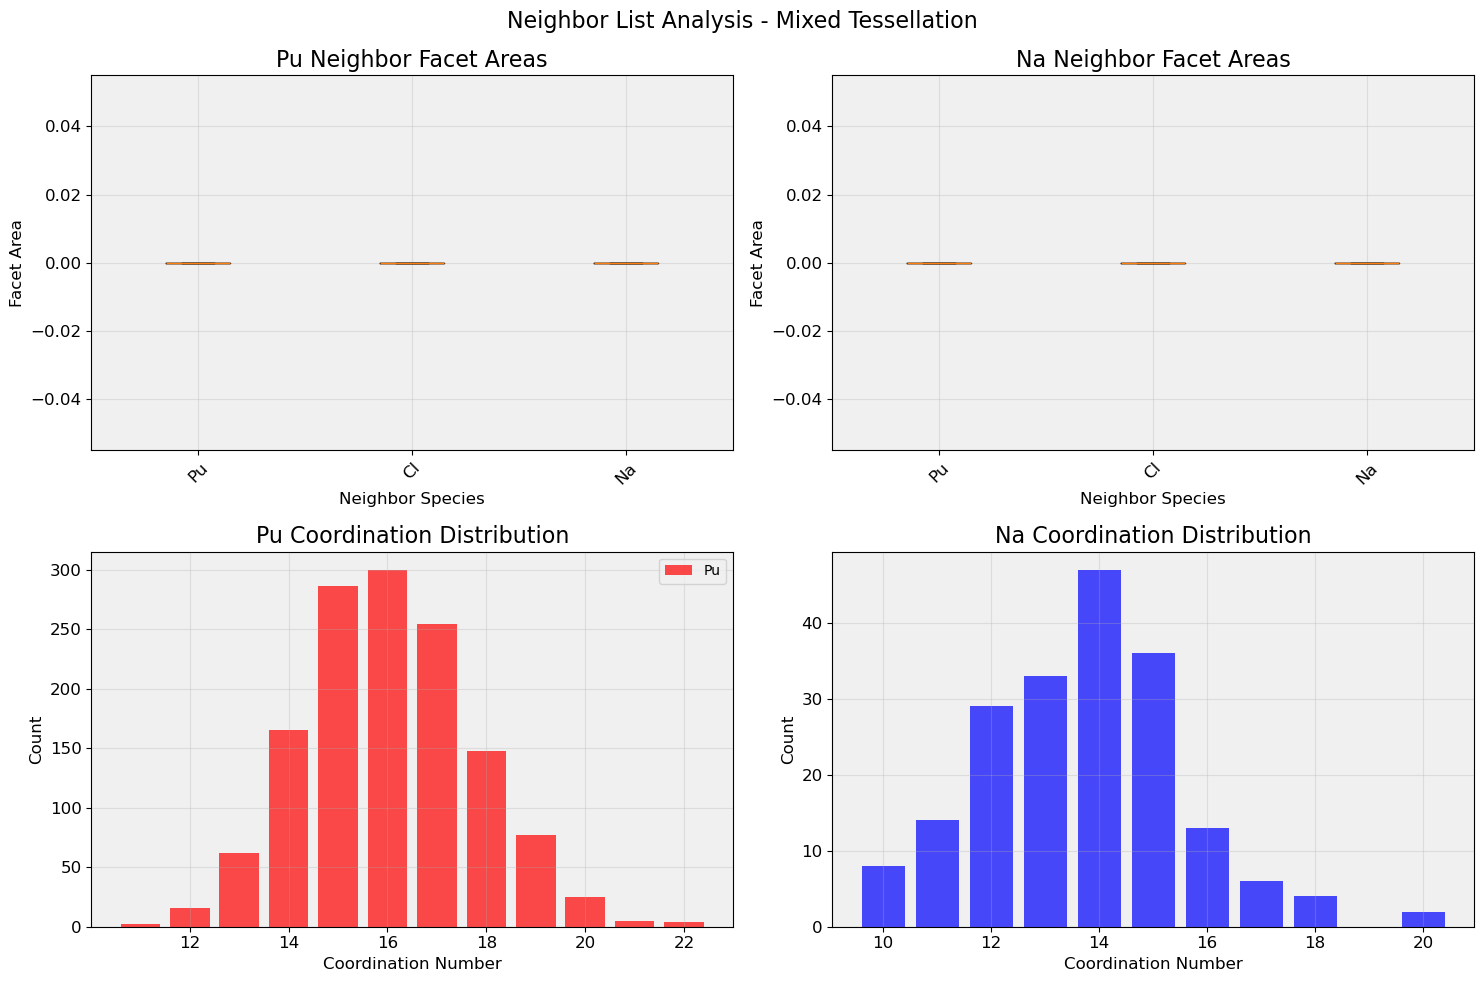

In [20]:
# Neighbor list analysis for detailed understanding
print("Neighbor List Analysis:")
print("=" * 50)

# Analyze neighbor list for Pu atoms
pu_atoms_with_neighbors = 0
pu_total_neighbors = 0
pu_na_neighbors = 0
pu_pu_neighbors = 0
pu_cl_neighbors = 0

for atom_idx, neighbors in neighbor_list.items():
    if atom_idx < len(names) and names[atom_idx] == "Pu":
        pu_atoms_with_neighbors += 1
        pu_total_neighbors += len(neighbors)
        
        for neighbor_idx, neighbor_species, area in neighbors:
            if neighbor_species == "Na":
                pu_na_neighbors += 1
            elif neighbor_species == "Pu":
                pu_pu_neighbors += 1
            elif neighbor_species == "Cl":
                pu_cl_neighbors += 1

print(f"Pu atoms with neighbors: {pu_atoms_with_neighbors}")
print(f"Total Pu neighbors: {pu_total_neighbors}")
print(f"Pu-Na neighbors: {pu_na_neighbors}")
print(f"Pu-Pu neighbors: {pu_pu_neighbors}")
print(f"Pu-Cl neighbors: {pu_cl_neighbors}")

if pu_atoms_with_neighbors > 0:
    print(f"Average neighbors per Pu atom: {pu_total_neighbors / pu_atoms_with_neighbors:.2f}")
    print(f"Average Na neighbors per Pu atom: {pu_na_neighbors / pu_atoms_with_neighbors:.2f}")
    print(f"Average Pu neighbors per Pu atom: {pu_pu_neighbors / pu_atoms_with_neighbors:.2f}")
    print(f"Average Cl neighbors per Pu atom: {pu_cl_neighbors / pu_atoms_with_neighbors:.2f}")

# Plot neighbor list analysis
plot_neighbor_list_analysis(neighbor_list, names, title="Neighbor List Analysis - Mixed Tessellation")


- Lower conc
- Without Na you do
- last hunder snapshots and avg them
- cluster size as a func of conc
- histogram of CN distribution
- how does avg coordination number change when you change all these parameters.

- Look at distribution of coordination number
- what did we use as our thesholds

In [21]:
from voronoi_ovito_utils import analyze_voronoi_coordination_all_methods

results_weighted = analyze_voronoi_coordination_all_methods(voronoi_graph, positions, tau=0.5)
cn_faces = results_weighted['CN_faces']
cn_area = results_weighted['CN_A']
cn_omega = results_weighted['CN_Ω']

Species found: ['Cl', 'Na', 'Pu']

Number of atoms: 1920

Plotting Cl coordination distributions...
  Topological (Face Count): μ=16.04, σ=1.73, n=1344
  Area-Weighted: μ=0.00, σ=0.00, n=1344
  Solid-Angle Weighted: μ=0.00, σ=0.00, n=1344

Plotting Na coordination distributions...
  Topological (Face Count): μ=13.70, σ=1.86, n=192
  Area-Weighted: μ=0.00, σ=0.00, n=192
  Solid-Angle Weighted: μ=0.00, σ=0.00, n=192

Plotting Pu coordination distributions...
  Topological (Face Count): μ=10.50, σ=1.33, n=384
  Area-Weighted: μ=0.00, σ=0.00, n=384
  Solid-Angle Weighted: μ=0.00, σ=0.00, n=384


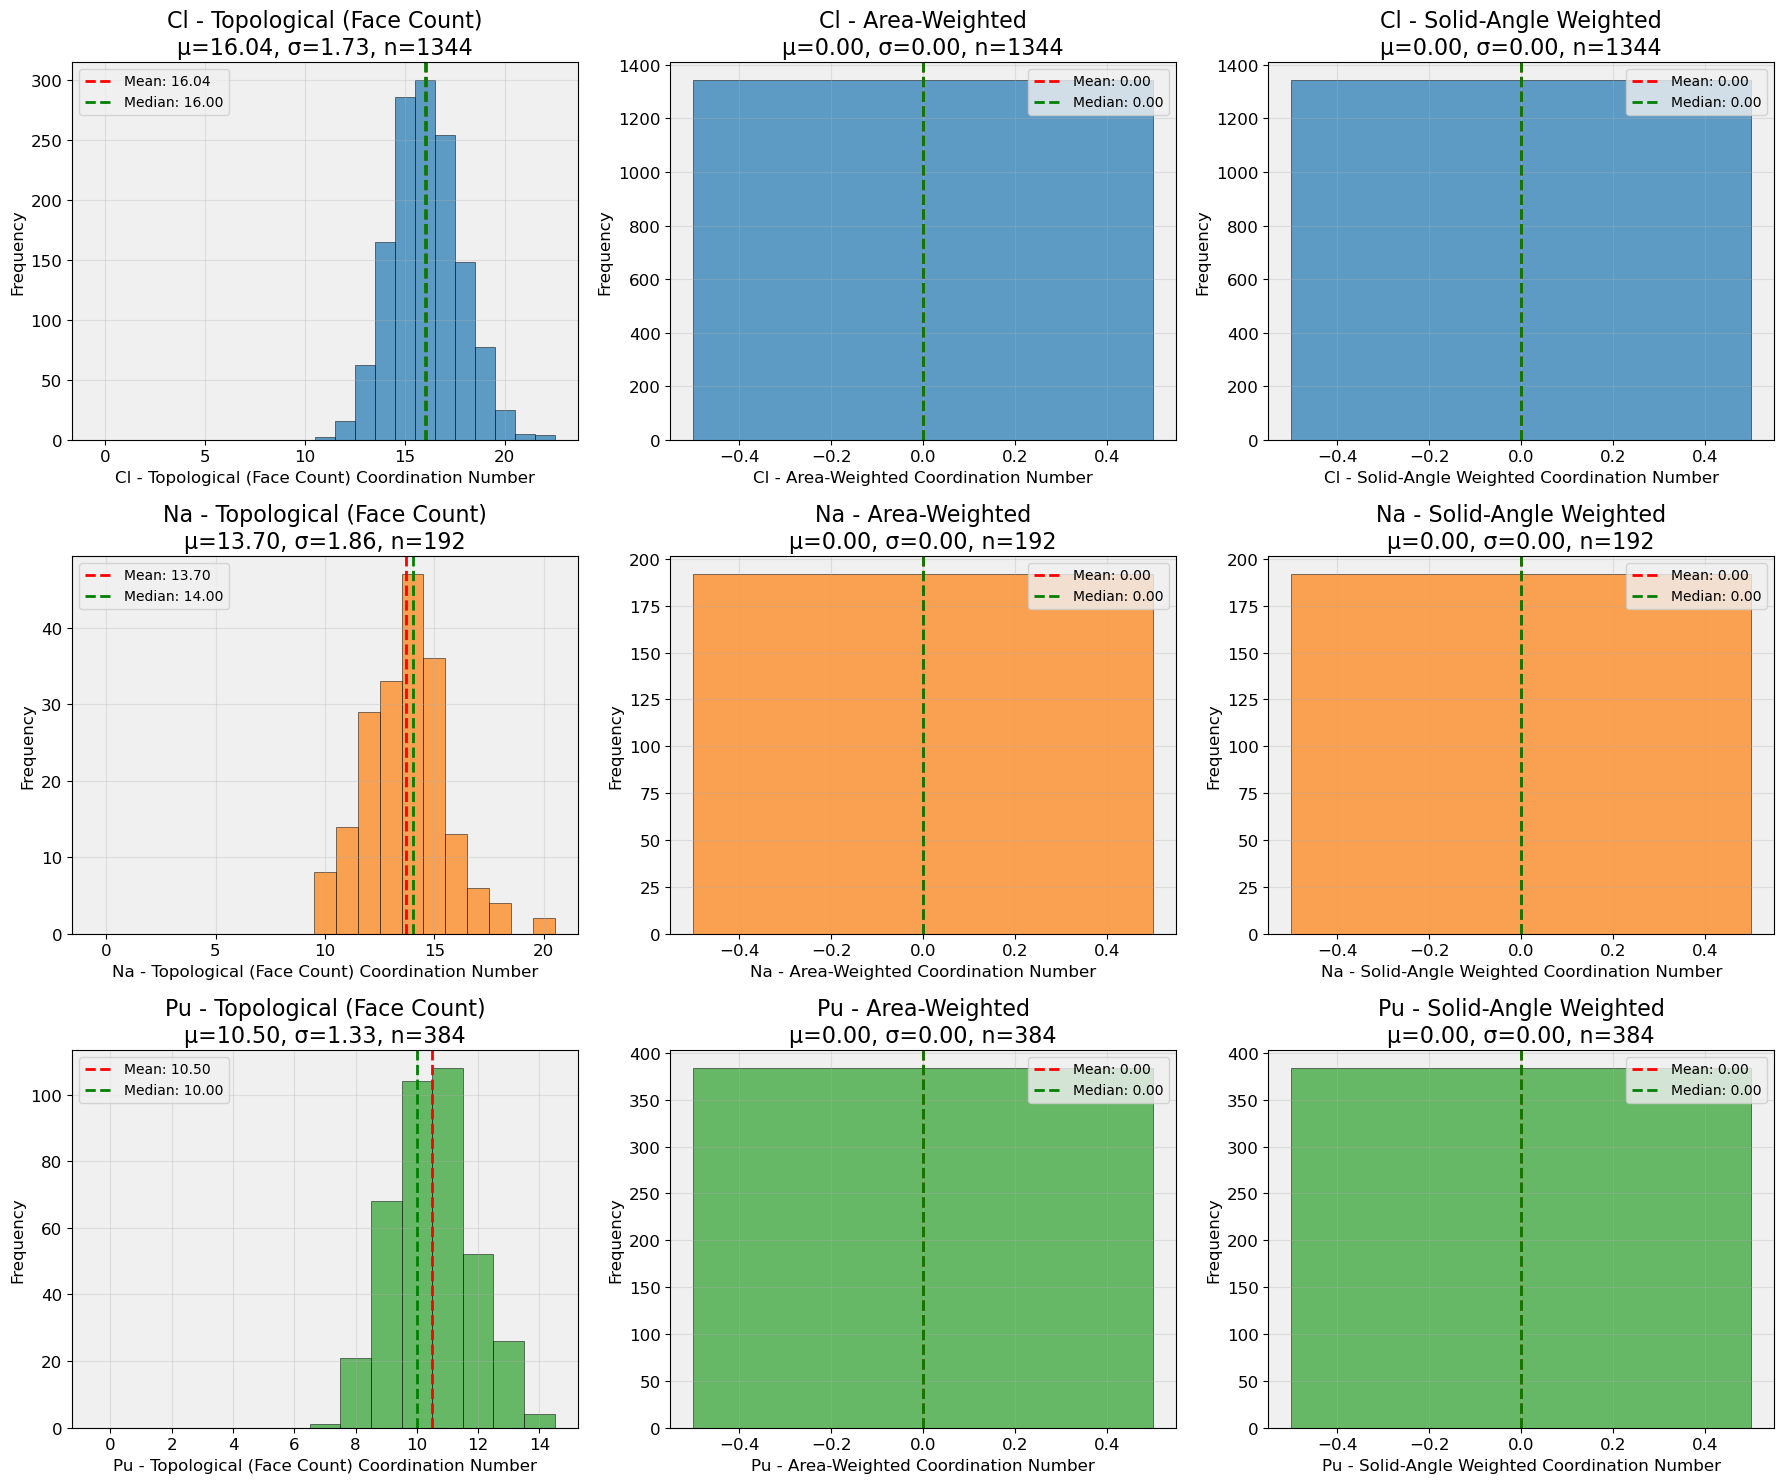


COMPARISON: Topological Coordination Number (CN_faces) across species
Cl: μ=16.04 ± 1.73 (n=1344)
Na: μ=13.70 ± 1.86 (n=192)
Pu: μ=10.50 ± 1.33 (n=384)


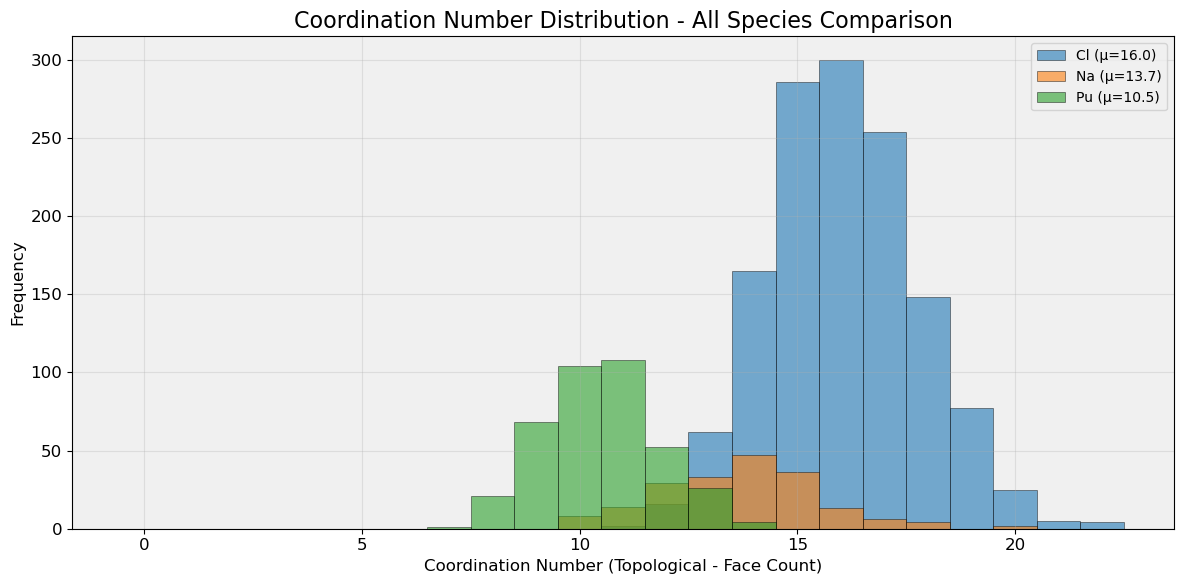


HISTOGRAM GENERATION COMPLETE


In [22]:
# Generate histograms from Voronoi coordination analysis
import matplotlib.pyplot as plt
import numpy as np

# Get species information
species_info = {idx: voronoi_graph.nodes[idx].get('species') for idx in voronoi_graph.nodes()}

# Extract coordination numbers by species for each method
def extract_cn_by_species(cn_dict, species_dict, species_name):
    """Extract coordination numbers for a specific species."""
    return [cn_dict[atom_idx] for atom_idx, species in species_dict.items() 
            if species == species_name and atom_idx in cn_dict]

# Get species
unique_species = sorted(list(set(species_info.values())))
print(f"Species found: {unique_species}")
print(f"\nNumber of atoms: {len(species_info)}")

# Create comprehensive histograms comparing all methods
fig, axes = plt.subplots(len(unique_species), 3, figsize=(18, 5*len(unique_species)))
if len(unique_species) == 1:
    axes = axes.reshape(1, -1)

methods = [
    ('CN_faces', cn_faces, 'Topological (Face Count)'),
    ('CN_A', cn_area, 'Area-Weighted'),
    ('CN_Ω', cn_omega, 'Solid-Angle Weighted')
]

for species_idx, species in enumerate(unique_species):
    print(f"\nPlotting {species} coordination distributions...")
    
    for method_idx, (method_key, cn_dict, method_name) in enumerate(methods):
        ax = axes[species_idx, method_idx]
        
        # Extract coordination numbers for this species
        cn_values = extract_cn_by_species(cn_dict, species_info, species)
        
        if cn_values:
            # Create histogram
            bins = np.arange(0, max(cn_values) + 2) - 0.5
            counts, edges, patches = ax.hist(cn_values, bins=bins, alpha=0.7, 
                                           edgecolor='black', linewidth=0.5,
                                           color=plt.cm.tab10(species_idx))
            
            # Add statistics
            mean_cn = np.mean(cn_values)
            std_cn = np.std(cn_values)
            median_cn = np.median(cn_values)
            
            ax.axvline(mean_cn, color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {mean_cn:.2f}')
            ax.axvline(median_cn, color='green', linestyle='--', linewidth=2, 
                      label=f'Median: {median_cn:.2f}')
            
            ax.set_xlabel(f'{species} - {method_name} Coordination Number')
            ax.set_ylabel('Frequency')
            ax.set_title(f'{species} - {method_name}\nμ={mean_cn:.2f}, σ={std_cn:.2f}, n={len(cn_values)}')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            print(f"  {method_name}: μ={mean_cn:.2f}, σ={std_cn:.2f}, n={len(cn_values)}")
        else:
            ax.text(0.5, 0.5, f'No data for {species}\n({method_name})', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{species} - {method_name}')

plt.tight_layout()
plt.show()

# Alternative: Single-method comparison across all species
print("\n" + "="*60)
print("COMPARISON: Topological Coordination Number (CN_faces) across species")
print("="*60)

fig, ax = plt.subplots(figsize=(12, 6))

for species in unique_species:
    cn_values = extract_cn_by_species(cn_faces, species_info, species)
    if cn_values:
        mean_cn = np.mean(cn_values)
        std_cn = np.std(cn_values)
        print(f"{species}: μ={mean_cn:.2f} ± {std_cn:.2f} (n={len(cn_values)})")
        
        ax.hist(cn_values, bins=np.arange(0, max(cn_values)+2)-0.5, alpha=0.6,
               label=f'{species} (μ={mean_cn:.1f})', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Coordination Number (Topological - Face Count)')
ax.set_ylabel('Frequency')
ax.set_title('Coordination Number Distribution - All Species Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("HISTOGRAM GENERATION COMPLETE")
print("="*60)

In [23]:
# Weighted coordination analysis by species
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')
from voronoi_coordination import analyze_weighted_coordination_by_species

# Extract positions from graph or use the positions array you already have
positions = np.array([voronoi_graph.nodes[idx].get('position') for idx in voronoi_graph.nodes()])

# Get species information  
names = extract_names_from_data(data0)

# Analyze weighted coordination organized by species pairs
# Available methods: "topological", "area_weighted", "solid_angle_weighted", "crystal_nn"
coord_data_weighted = analyze_weighted_coordination_by_species(
    voronoi_graph, 
    names, 
    positions=positions, 
    method="area_weighted",  # or "solid_angle_weighted", "crystal_nn"
    min_area=0.0
)

print("Weighted coordination analysis complete!")
print(f"Sample coordination structure:")
print(f"Pu->Cl coordination: {coord_data_weighted['Pu']['Cl'][:5]}")  # First 5 Pu atoms
print(f"Pu->Na coordination: {coord_data_weighted['Pu']['Na'][:5]}")
print(f"Pu->Pu coordination: {coord_data_weighted['Pu']['Pu'][:5]}")
print(f"\nPu total coordination (any): {coord_data_weighted['Pu']['any'][:5]}")

# Compute mean coordination for each species pair
print("\n" + "="*60)
print("MEAN COORDINATION (Area-Weighted)")
print("="*60)

for central_sp in ['Pu', 'Na', 'Cl']:
    print(f"\n{central_sp}:")
    for neighbor_sp in ['Pu', 'Na', 'Cl']:
        counts = coord_data_weighted[central_sp][neighbor_sp]
        if counts and sum(counts) > 0:
            mean_coord = np.mean(counts)
            std_coord = np.std(counts)
            print(f"  -> {neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f}")


TypeError: analyze_weighted_coordination_by_species() got an unexpected keyword argument 'positions'

In [ ]:
cn_faces

{0: 16,
 1: 16,
 2: 9,
 3: 14,
 4: 11,
 5: 11,
 6: 15,
 7: 14,
 8: 16,
 9: 15,
 10: 16,
 11: 15,
 12: 14,
 13: 9,
 14: 10,
 15: 17,
 16: 16,
 17: 16,
 18: 10,
 19: 15,
 20: 15,
 21: 14,
 22: 12,
 23: 15,
 24: 17,
 25: 16,
 26: 10,
 27: 16,
 28: 13,
 29: 10,
 30: 14,
 31: 13,
 32: 18,
 33: 15,
 34: 17,
 35: 16,
 36: 17,
 37: 15,
 38: 15,
 39: 9,
 40: 16,
 41: 18,
 42: 17,
 43: 13,
 44: 14,
 45: 8,
 46: 14,
 47: 11,
 48: 18,
 49: 7,
 50: 16,
 51: 18,
 52: 14,
 53: 15,
 54: 10,
 55: 19,
 56: 17,
 57: 15,
 58: 15,
 59: 15,
 60: 11,
 61: 17,
 62: 19,
 63: 14,
 64: 10,
 65: 10,
 66: 17,
 67: 14,
 68: 16,
 69: 14,
 70: 19,
 71: 15,
 72: 14,
 73: 11,
 74: 15,
 75: 16,
 76: 14,
 77: 19,
 78: 11,
 79: 14,
 80: 16,
 81: 9,
 82: 17,
 83: 9,
 84: 18,
 85: 13,
 86: 15,
 87: 13,
 88: 8,
 89: 16,
 90: 19,
 91: 17,
 92: 17,
 93: 12,
 94: 14,
 95: 15,
 96: 10,
 97: 17,
 98: 19,
 99: 13,
 100: 16,
 101: 13,
 102: 14,
 103: 17,
 104: 13,
 105: 18,
 106: 16,
 107: 16,
 108: 12,
 109: 14,
 110: 15,
 111: 17

VORONOI COORDINATION HISTOGRAM ANALYSIS
Analyzing Voronoi coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]

Plotting coordination histogram for Pu:
{np.str_('Cl'): [2, 3, 3, 4, 3, 3, 4, 3, 3, 3, 2, 4, 3, 2, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 2, 3, 2, 3, 3, 4, 2, 3, 5, 3, 3, 2, 2, 4, 4, 3, 4, 2, 4, 3, 3, 3, 2, 2, 4, 2, 2, 1, 2, 4, 4, 4, 5, 4, 3, 3, 3, 4, 3, 2, 3, 2, 3, 4, 1, 1, 1, 2, 4, 3, 2, 4, 4, 3, 4, 3, 4, 4, 1, 2, 3, 4, 3, 2, 3, 4, 3, 4, 3, 3, 2, 1, 2, 3, 3, 3, 2, 5, 3, 2, 3, 2, 3, 2, 3, 2, 3, 3, 5, 3, 3, 3, 3, 2, 4, 5, 2, 2, 1, 2, 3, 4, 4, 5, 2, 3, 2, 3, 3, 3, 3, 2, 3, 3, 2, 3, 4, 3, 2, 3, 3, 2, 2, 2, 2, 4, 1, 2, 2, 3, 4, 4, 4, 3, 2, 2, 4, 2, 3, 4, 2, 2, 3, 3, 2, 2, 3, 5, 4, 3, 2, 2, 2, 2, 3, 2, 2, 4, 2, 2, 3, 3, 2, 3, 5, 3, 3, 4, 2, 1, 2, 3, 1, 2, 4, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 5, 3, 2, 2, 4, 2, 4, 4, 2, 4, 4, 3, 2, 2, 3, 5, 3, 3, 3, 2, 3, 2, 4, 3, 2, 4, 2, 4, 3, 3, 3, 3, 2, 2, 3, 3, 3, 3, 3, 2, 2, 2, 4, 2, 4, 3, 2, 3, 1, 2, 3, 3, 3, 2, 3, 3, 3, 2, 4, 2, 3, 3,

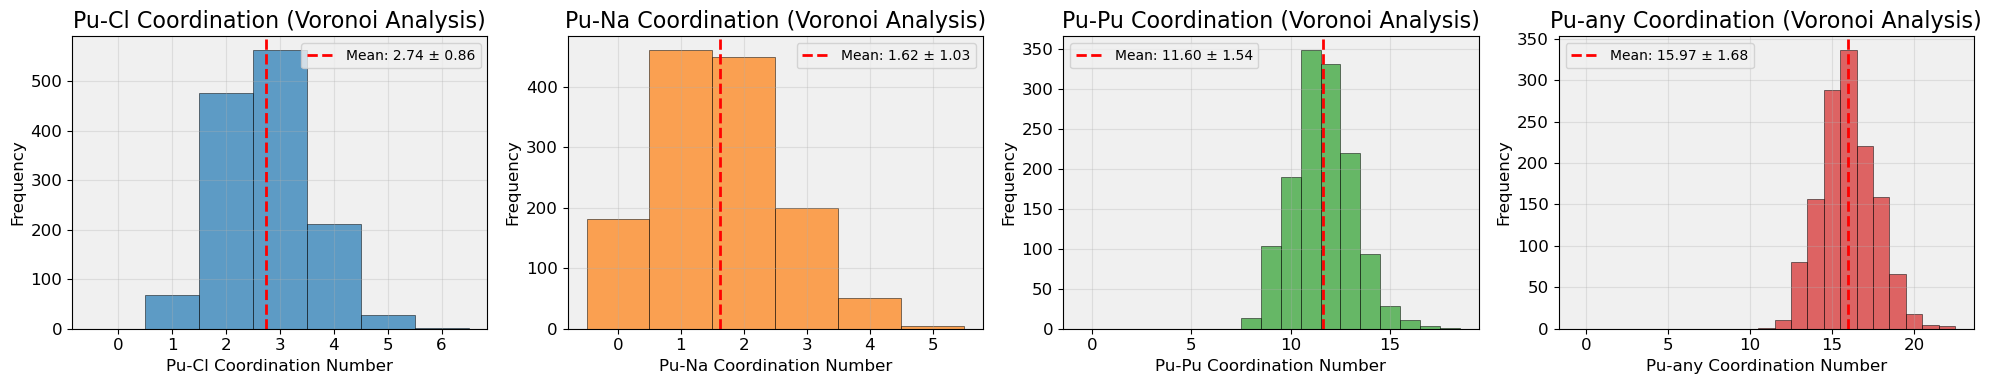


Plotting coordination histogram for Na:
{np.str_('Cl'): [0, 2, 2, 3, 2, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 1, 1, 1, 3, 0, 2, 2, 0, 1, 2, 3, 1, 1, 1, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 1, 0, 1, 0, 2, 0, 1, 1, 3, 0, 0, 1, 2, 4, 2, 2, 1, 0, 2, 3, 0, 1, 1, 2, 1, 3, 2, 2, 3, 0, 0, 2, 0, 0, 1, 1, 1, 1, 2, 1, 1, 1, 3, 2, 0, 3, 2, 0, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 2, 2, 2, 1, 3, 1, 1, 3, 0, 1, 2, 0, 0, 1, 3, 4, 0, 2, 1, 0, 1, 2, 0, 1, 2, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 3, 2, 0, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 3, 3, 1, 2, 1, 1, 0, 0, 1, 4, 0, 1, 2, 1, 0, 1, 2, 0, 1, 0, 0, 3, 3, 0, 1, 0, 1, 2, 1], np.str_('Na'): [1, 1, 0, 0, 0, 3, 0, 2, 2, 1, 0, 1, 2, 1, 3, 1, 1, 1, 1, 0, 1, 0, 1, 2, 3, 0, 1, 1, 2, 2, 1, 3, 3, 0, 2, 1, 0, 1, 1, 2, 1, 0, 2, 1, 0, 3, 1, 1, 0, 1, 2, 0, 2, 3, 1, 2, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 0, 2, 2, 1, 2, 1, 0, 2, 2, 2, 1, 2, 1, 2, 3, 0, 1, 2, 3, 1, 3, 3, 3, 0, 1, 0, 0, 1, 1, 0, 2, 0, 0, 2, 3, 2, 0, 2, 3, 2, 3, 1, 1, 0, 1, 1, 1, 0, 2, 0, 0

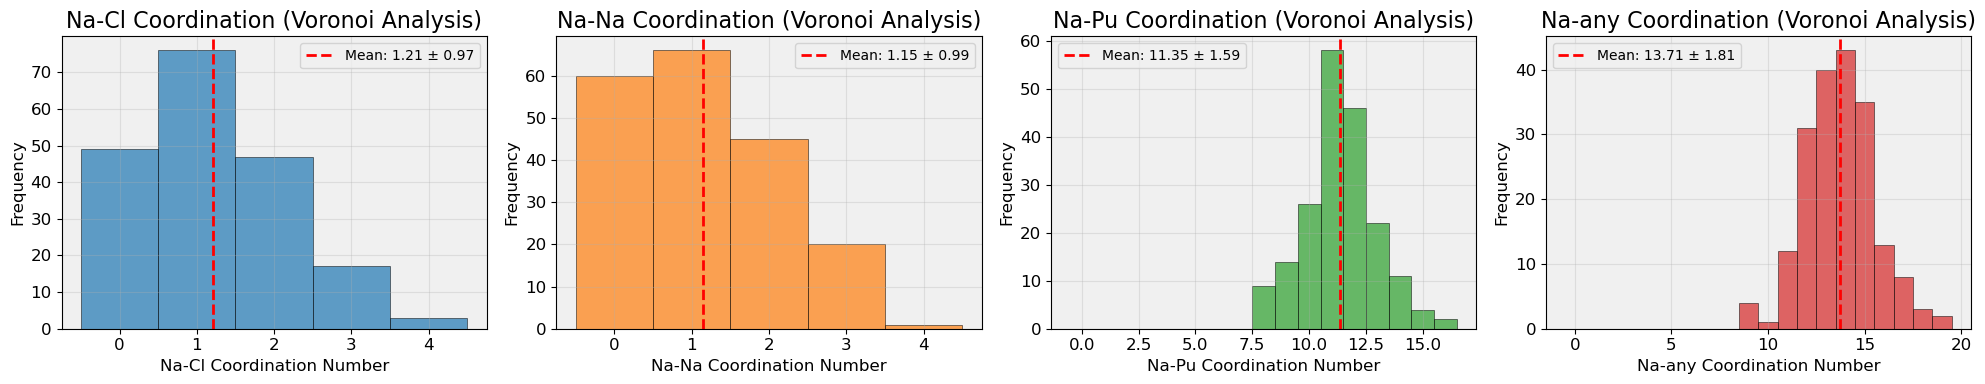


Plotting coordination histogram for Cl:
{np.str_('Cl'): [0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 3, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 1, 1, 2, 1, 1, 1, 2, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 

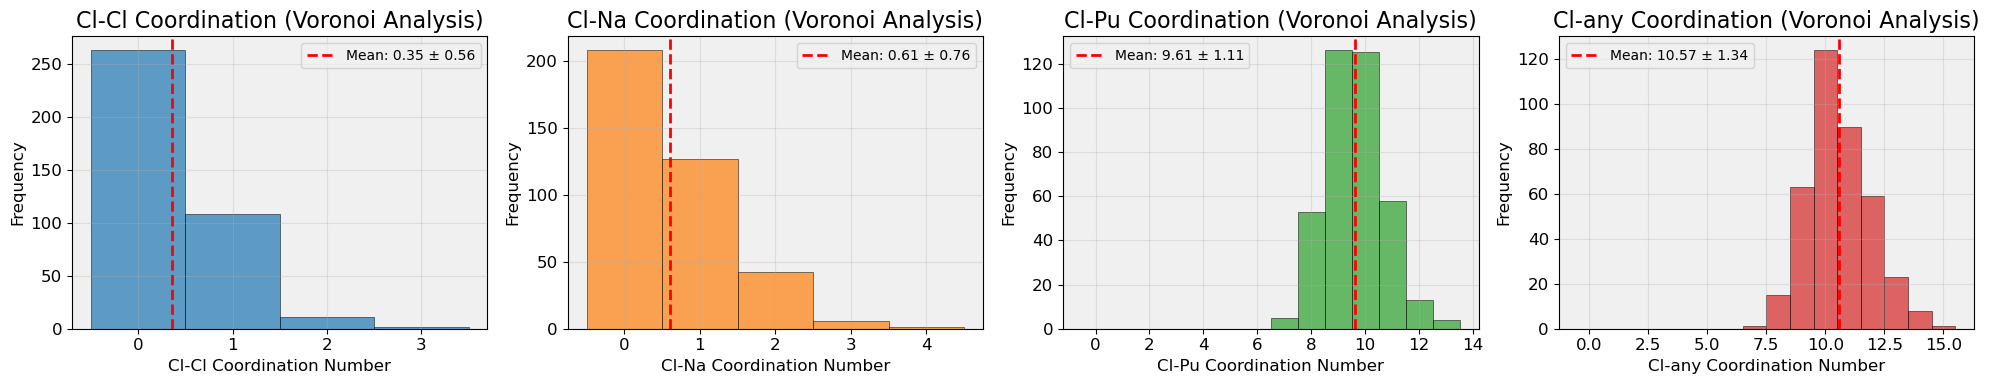


VORONOI COORDINATION ANALYSIS COMPLETE


In [ ]:
def analyze_voronoi_coordination(voronoi_graph, names, min_area=0.0):
    """
    Analyze coordination using Voronoi tessellation analysis.
    
    This function computes neighbor-count distributions by species using the Voronoi graph,
    making it suitable for Voronoi-based cluster analysis.
    
    Parameters:
        voronoi_graph: NetworkX graph built from Voronoi tessellation
        names: Array of atom names/types
        min_area: Minimum facet area threshold for including neighbors
    
    Returns:
        dict: Coordination data organized by central species and neighbor species
              Includes additional 'any' coordination structures:
              - coord_data[sp_c]['any']: total coordination for each central species
              - coord_data['any'][sp_n]: coordination from any central species to each neighbor species
              - coord_data['any']['any']: total coordination across all species pairs
    """
    import numpy as np
    from collections import defaultdict
    
    # Get unique species
    unique_species = sorted(list(set(names)))
    print(f"Analyzing Voronoi coordination for species: {unique_species}")
    
    # Initialize coordination data structure
    coord_data = {sp_c: {sp_n: [] for sp_n in unique_species} for sp_c in unique_species}
    
    # Add 'any' coordination structures
    coord_data['any'] = {sp_n: [] for sp_n in unique_species}
    coord_data['any']['any'] = []
    
    # Calculate coordination for each atom from Voronoi graph
    for i in range(len(names)):
        sp_i = names[i]
        neighbors = []
        
        # Get neighbors from Voronoi graph if node exists
        if i in voronoi_graph:
            # Get all neighbors for this atom
            for neighbor_idx in voronoi_graph.neighbors(i):
                # Check facet area if available
                edge_data = voronoi_graph.get_edge_data(i, neighbor_idx, {})
                facet_area = edge_data.get('facet_area', edge_data.get('area', 0.0))
                
                # Only include neighbors if facet area is above threshold
                if facet_area >= min_area:
                    if neighbor_idx < len(names):
                        neighbors.append(names[neighbor_idx])
        
        # Store coordination counts for specific species pairs
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data[sp_i][neighbor_sp].append(count)
        
        # Store total coordination for this central species (any neighbors)
        total_coord = len(neighbors)
        coord_data[sp_i]['any'] = coord_data[sp_i].get('any', [])
        coord_data[sp_i]['any'].append(total_coord)
        
        # Store coordination counts for 'any' central species to each neighbor species
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data['any'][neighbor_sp].append(count)
        
        # Store total coordination for 'any'-'any' (all coordination)
        coord_data['any']['any'].append(total_coord)
    
    return coord_data

def plot_voronoi_coordination_histograms(coord_data, central_species, title_suffix=""):
    """
    Plot coordination histograms for Voronoi-based analysis.
    
    Parameters:
        coord_data: Coordination data from analyze_voronoi_coordination
        central_species: Species to plot coordination for
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if central_species not in coord_data:
        print(f"No coordination data found for species: {central_species}")
        return
    
    # Get coordination data for the central species
    species_data = coord_data[central_species]
    print(species_data)
    
    # Filter out empty neighbor species
    neighbor_species = [sp for sp, counts in species_data.items() if counts and any(counts)]
    print(neighbor_species)
    
    if not neighbor_species:
        print(f"No coordination data found for {central_species}")
        return
    
    # Create subplots
    n_neighbors = len(neighbor_species)
    fig, axes = plt.subplots(1, n_neighbors, figsize=(5*n_neighbors, 4))
    if n_neighbors == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, neighbor_sp in enumerate(neighbor_species):
        counts = species_data[neighbor_sp]
        
        if not counts:
            continue
            
        # Create histogram
        max_coord = max(counts) if counts else 0
        bins = np.arange(0, max_coord + 2) - 0.5
        
        axes[idx].hist(counts, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                      edgecolor='black', linewidth=0.5)
        
        # Add statistics
        mean_coord = np.mean(counts)
        std_coord = np.std(counts)
        axes[idx].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
        
        axes[idx].set_xlabel(f'{central_species}-{neighbor_sp} Coordination Number')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{central_species}-{neighbor_sp} Coordination{title_suffix}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # Print statistics
        print(f'{central_species}-{neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
    
    plt.tight_layout()
    plt.show()

# Test the coordination analysis with current data
print("=" * 60)
print("VORONOI COORDINATION HISTOGRAM ANALYSIS")
print("=" * 60)

# Analyze coordination using Voronoi graph
coord_data = analyze_voronoi_coordination(voronoi_graph, names, min_area=0.0)

# Plot coordination histograms for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data and any(any(counts) for counts in coord_data[species].values()):
        print(f"\nPlotting coordination histogram for {species}:")
        plot_voronoi_coordination_histograms(coord_data, species, " (Voronoi Analysis)")
    else:
        print(f"No coordination data available for {species}")

print("\n" + "=" * 60)
print("VORONOI COORDINATION ANALYSIS COMPLETE")
print("=" * 60)


In [ ]:
# Test the enhanced coordination analysis function
print("=" * 60)
print("TESTING ENHANCED COORDINATION ANALYSIS")
print("=" * 60)

# Re-run the enhanced coordination analysis
coord_data_enhanced = analyze_voronoi_coordination(voronoi_graph, names, min_area=0.0)

# Verify all coordination structures are present
print("\nVerifying coordination data structures:")
print("-" * 40)

# Check species-specific coordination
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data_enhanced:
        print(f"\n{species} coordination data:")
        for neighbor_sp in ['Pu', 'Na', 'Cl', 'any']:
            if neighbor_sp in coord_data_enhanced[species]:
                counts = coord_data_enhanced[species][neighbor_sp]
                if counts:
                    mean_coord = np.mean(counts)
                    print(f"  {species}-{neighbor_sp}: {mean_coord:.2f} ± {np.std(counts):.2f} (n={len(counts)})")
                else:
                    print(f"  {species}-{neighbor_sp}: No data")

# Check 'any' central species coordination
print(f"\n'any' central species coordination data:")
for neighbor_sp in ['Pu', 'Na', 'Cl', 'any']:
    if neighbor_sp in coord_data_enhanced['any']:
        counts = coord_data_enhanced['any'][neighbor_sp]
        if counts:
            mean_coord = np.mean(counts)
            print(f"  any-{neighbor_sp}: {mean_coord:.2f} ± {np.std(counts):.2f} (n={len(counts)})")
        else:
            print(f"  any-{neighbor_sp}: No data")

# Verify data consistency
print(f"\nData consistency checks:")
print("-" * 40)

# Check that 'any' coordination equals sum of specific coordinations for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data_enhanced and 'any' in coord_data_enhanced[species]:
        any_coord = coord_data_enhanced[species]['any']
        specific_coord_sum = []
        
        # Sum up specific coordinations for this species
        for neighbor_sp in ['Pu', 'Na', 'Cl']:
            if neighbor_sp in coord_data_enhanced[species]:
                specific_coord_sum.extend(coord_data_enhanced[species][neighbor_sp])
        
        if any_coord and specific_coord_sum:
            any_mean = np.mean(any_coord)
            specific_mean = np.mean(specific_coord_sum)
            diff = abs(any_mean - specific_mean)
            status = "✓" if diff < 0.01 else "✗"
            print(f"  {species} any vs sum of specific: {any_mean:.2f} vs {specific_mean:.2f} (diff: {diff:.3f}) {status}")

# Check that 'any'-'any' equals sum of all 'any' coordinations
if 'any' in coord_data_enhanced and 'any' in coord_data_enhanced['any']:
    any_any_coord = coord_data_enhanced['any']['any']
    all_any_coord = []
    
    # Sum up all 'any' coordinations
    for species in ['Pu', 'Na', 'Cl']:
        if species in coord_data_enhanced and 'any' in coord_data_enhanced[species]:
            all_any_coord.extend(coord_data_enhanced[species]['any'])
    
    if any_any_coord and all_any_coord:
        any_any_mean = np.mean(any_any_coord)
        all_any_mean = np.mean(all_any_coord)
        diff = abs(any_any_mean - all_any_mean)
        status = "✓" if diff < 0.01 else "✗"
        print(f"  any-any vs sum of all any: {any_any_mean:.2f} vs {all_any_mean:.2f} (diff: {diff:.3f}) {status}")

print("\n" + "=" * 60)
print("ENHANCED COORDINATION ANALYSIS TEST COMPLETE")
print("=" * 60)


TESTING ENHANCED COORDINATION ANALYSIS
Analyzing Voronoi coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]

Verifying coordination data structures:
----------------------------------------

Pu coordination data:
  Pu-Pu: 11.60 ± 1.54 (n=1344)
  Pu-Na: 1.62 ± 1.03 (n=1344)
  Pu-Cl: 2.74 ± 0.86 (n=1344)
  Pu-any: 15.97 ± 1.68 (n=1344)

Na coordination data:
  Na-Pu: 11.35 ± 1.59 (n=192)
  Na-Na: 1.15 ± 0.99 (n=192)
  Na-Cl: 1.21 ± 0.97 (n=192)
  Na-any: 13.71 ± 1.81 (n=192)

Cl coordination data:
  Cl-Pu: 9.61 ± 1.11 (n=384)
  Cl-Na: 0.61 ± 0.76 (n=384)
  Cl-Cl: 0.35 ± 0.56 (n=384)
  Cl-any: 10.57 ± 1.34 (n=384)

'any' central species coordination data:
  any-Pu: 11.18 ± 1.67 (n=1920)
  any-Na: 1.37 ± 1.06 (n=1920)
  any-Cl: 2.11 ± 1.29 (n=1920)
  any-any: 14.66 ± 2.70 (n=1920)

Data consistency checks:
----------------------------------------
  Pu any vs sum of specific: 15.97 vs 5.32 (diff: 10.647) ✗
  Na any vs sum of specific: 13.71 vs 4.57 (diff: 9.142) ✗
  Cl 

In [24]:
# Demonstrate plotting with the new 'any' coordination structures
print("=" * 60)
print("PLOTTING NEW COORDINATION STRUCTURES")
print("=" * 60)

def plot_any_coordination_histograms(coord_data, title_suffix=""):
    """
    Plot histograms for the new 'any' coordination structures.
    
    Parameters:
        coord_data: Enhanced coordination data with 'any' structures
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Enhanced Coordination Analysis{title_suffix}', fontsize=16, fontweight='bold')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Plot 1: Pu-any coordination
    if 'Pu' in coord_data and 'any' in coord_data['Pu']:
        pu_any = coord_data['Pu']['any']
        if pu_any:
            max_coord = max(pu_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[0,0].hist(pu_any, bins=bins, alpha=0.7, color=colors[0], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(pu_any)
            std_coord = np.std(pu_any)
            axes[0,0].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[0,0].set_xlabel('Pu Total Coordination Number')
            axes[0,0].set_ylabel('Frequency')
            axes[0,0].set_title('Pu-Any Coordination')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
            
            print(f'Pu-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(pu_any)})')
    
    # Plot 2: Na-any coordination
    if 'Na' in coord_data and 'any' in coord_data['Na']:
        na_any = coord_data['Na']['any']
        if na_any:
            max_coord = max(na_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[0,1].hist(na_any, bins=bins, alpha=0.7, color=colors[1], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(na_any)
            std_coord = np.std(na_any)
            axes[0,1].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[0,1].set_xlabel('Na Total Coordination Number')
            axes[0,1].set_ylabel('Frequency')
            axes[0,1].set_title('Na-Any Coordination')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
            
            print(f'Na-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(na_any)})')
    
    # Plot 3: Cl-any coordination
    if 'Cl' in coord_data and 'any' in coord_data['Cl']:
        cl_any = coord_data['Cl']['any']
        if cl_any:
            max_coord = max(cl_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[1,0].hist(cl_any, bins=bins, alpha=0.7, color=colors[2], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(cl_any)
            std_coord = np.std(cl_any)
            axes[1,0].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[1,0].set_xlabel('Cl Total Coordination Number')
            axes[1,0].set_ylabel('Frequency')
            axes[1,0].set_title('Cl-Any Coordination')
            axes[1,0].legend()
            axes[1,0].grid(True, alpha=0.3)
            
            print(f'Cl-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(cl_any)})')
    
    # Plot 4: Any-any coordination (total system coordination)
    if 'any' in coord_data and 'any' in coord_data['any']:
        any_any = coord_data['any']['any']
        if any_any:
            max_coord = max(any_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[1,1].hist(any_any, bins=bins, alpha=0.7, color=colors[3], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(any_any)
            std_coord = np.std(any_any)
            axes[1,1].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[1,1].set_xlabel('Total Coordination Number')
            axes[1,1].set_ylabel('Frequency')
            axes[1,1].set_title('Any-Any Coordination (Total System)')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
            
            print(f'Any-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(any_any)})')
    
    plt.tight_layout()
    plt.show()

# Plot the new coordination structures
plot_any_coordination_histograms(coord_data_enhanced, " (Enhanced Bond-based Analysis)")

print("\n" + "=" * 60)
print("ENHANCED COORDINATION PLOTTING COMPLETE")
print("=" * 60)


PLOTTING NEW COORDINATION STRUCTURES


NameError: name 'coord_data_enhanced' is not defined

In [25]:
results = analyze_voronoi_coordination_all_methods(voronoi_graph, positions)

In [26]:
results.keys()

dict_keys(['CN_faces', 'CN_A', 'CN_A_weights', 'CN_Ω', 'CN_Ω_weights', 'CN_threshold', 'CrystalNN_weights'])

In [27]:
results['CN_A_weights']

{0: array([], dtype=float64),
 1: array([], dtype=float64),
 2: array([], dtype=float64),
 3: array([], dtype=float64),
 4: array([], dtype=float64),
 5: array([], dtype=float64),
 6: array([], dtype=float64),
 7: array([], dtype=float64),
 8: array([], dtype=float64),
 9: array([], dtype=float64),
 10: array([], dtype=float64),
 11: array([], dtype=float64),
 12: array([], dtype=float64),
 13: array([], dtype=float64),
 14: array([], dtype=float64),
 15: array([], dtype=float64),
 16: array([], dtype=float64),
 17: array([], dtype=float64),
 18: array([], dtype=float64),
 19: array([], dtype=float64),
 20: array([], dtype=float64),
 21: array([], dtype=float64),
 22: array([], dtype=float64),
 23: array([], dtype=float64),
 24: array([], dtype=float64),
 25: array([], dtype=float64),
 26: array([], dtype=float64),
 27: array([], dtype=float64),
 28: array([], dtype=float64),
 29: array([], dtype=float64),
 30: array([], dtype=float64),
 31: array([], dtype=float64),
 32: array([], dty

In [28]:
results['CN_faces']

{0: 11,
 1: 18,
 2: 17,
 3: 17,
 4: 13,
 5: 19,
 6: 13,
 7: 18,
 8: 11,
 9: 18,
 10: 11,
 11: 16,
 12: 14,
 13: 12,
 14: 15,
 15: 18,
 16: 13,
 17: 17,
 18: 13,
 19: 15,
 20: 16,
 21: 17,
 22: 10,
 23: 15,
 24: 18,
 25: 15,
 26: 14,
 27: 16,
 28: 17,
 29: 17,
 30: 12,
 31: 17,
 32: 14,
 33: 16,
 34: 15,
 35: 14,
 36: 18,
 37: 14,
 38: 20,
 39: 15,
 40: 16,
 41: 13,
 42: 15,
 43: 15,
 44: 11,
 45: 17,
 46: 11,
 47: 17,
 48: 14,
 49: 13,
 50: 19,
 51: 14,
 52: 16,
 53: 17,
 54: 12,
 55: 16,
 56: 16,
 57: 13,
 58: 16,
 59: 17,
 60: 10,
 61: 13,
 62: 17,
 63: 9,
 64: 18,
 65: 14,
 66: 18,
 67: 12,
 68: 13,
 69: 14,
 70: 16,
 71: 15,
 72: 15,
 73: 15,
 74: 12,
 75: 16,
 76: 15,
 77: 17,
 78: 11,
 79: 16,
 80: 11,
 81: 8,
 82: 16,
 83: 15,
 84: 10,
 85: 14,
 86: 17,
 87: 16,
 88: 13,
 89: 10,
 90: 16,
 91: 16,
 92: 16,
 93: 13,
 94: 14,
 95: 15,
 96: 10,
 97: 18,
 98: 11,
 99: 20,
 100: 16,
 101: 15,
 102: 10,
 103: 10,
 104: 14,
 105: 17,
 106: 13,
 107: 15,
 108: 16,
 109: 14,
 110: 17,
 1

In [29]:
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')
from voronoi_coordination import compute_coordination_histogram_data

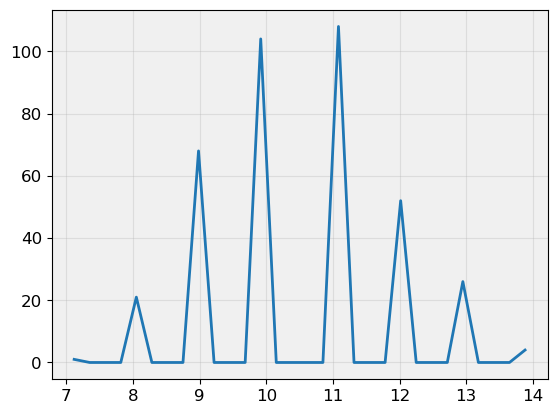

In [30]:
hist_data = compute_coordination_histogram_data(results['CN_faces'], voronoi_graph, bins=30)
plt.plot(hist_data['Pu']['bin_centers'], hist_data['Pu']['counts'], label='Pu')

In [31]:
cn_a

0.0